# Financial Risk Management and Engineering - Portfolio Exam
### A 20-stock S&P 500 book | FRME S26

The book is 20 S&P 500 names spanning all eleven GICS sectors, equal-weighted at
$1m. Citigroup (C), Boeing (BA) and Regeneron (REGN) are retained from the
three-stock version so the two can be read side by side; the other seventeen are
added to give the correlation, diversification, concentration and systemic-risk
sections a cross-section large enough to say something.

Scaling from three names to twenty changes three methods, each flagged where it
appears: the credit loss distribution is summed by conditional-independence
**recursion on a loss grid** rather than by enumerating 2^N outcomes
(2^20 = 1,048,576); the risk-parity solver uses the **fixed-point iteration**
rather than Nelder-Mead, which does not converge reliably in 20 dimensions; and
the rolling-correlation exhibit reports the **average pairwise** correlation plus
a sector-block heatmap rather than three individual pairs. The models themselves
are unchanged.

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 4)

AS_OF_DATE, LOOKBACK_YRS = '2026-07-01', 3
START_DATE = (pd.Timestamp(AS_OF_DATE) - pd.DateOffset(years=LOOKBACK_YRS)).strftime('%Y-%m-%d')

# 20 S&P 500 names, all eleven GICS sectors. C / BA / REGN are carried over from the
# three-stock version of this exam so the two are directly comparable.
SECTOR = {
    'C':    'Financials',      'JPM':  'Financials',        'GS':   'Financials',
    'BA':   'Industrials',     'CAT':  'Industrials',
    'REGN': 'Health Care',     'JNJ':  'Health Care',       'UNH':  'Health Care',
    'AAPL': 'Info Tech',       'MSFT': 'Info Tech',         'NVDA': 'Info Tech',
    'XOM':  'Energy',          'CVX':  'Energy',
    'PG':   'Cons Staples',    'KO':   'Cons Staples',
    'HD':   'Cons Disc',
    'NEE':  'Utilities',
    'LIN':  'Materials',
    'AMT':  'Real Estate',
    'VZ':   'Comm Services',
}
TICKERS = list(SECTOR)
N       = len(TICKERS)
BENCH   = '^GSPC'
SEED    = 42
SRC     = {}

SNAP_PX, SNAP_VOL = 'snapshot_prices_20.csv', 'snapshot_volume_20.csv'
REFRESH = False   # False loads the frozen snapshot; True re-pulls and overwrites it

if REFRESH or not os.path.exists(SNAP_PX):
    import yfinance as yf
    raw = yf.download(TICKERS + [BENCH], start=START_DATE,
                      end=(pd.Timestamp(AS_OF_DATE) + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                      auto_adjust=True, progress=False)
    PX  = raw['Close'][TICKERS + [BENCH]].dropna()
    VOL = raw['Volume'][TICKERS].reindex(PX.index)
    if PX.empty:
        raise RuntimeError('Yahoo returned no rows - do not overwrite the snapshot')
    PX.to_csv(SNAP_PX); VOL.to_csv(SNAP_VOL)
    print('SNAPSHOT WRITTEN from yfinance on %s - all later runs load this frozen file.'
          % pd.Timestamp.today().date())

PX  = pd.read_csv(SNAP_PX,  index_col=0, parse_dates=True)
VOL = pd.read_csv(SNAP_VOL, index_col=0, parse_dates=True)

SRC['prices'] = 'Yahoo Finance via yfinance, auto-adjusted close, pulled once and frozen to %s' % SNAP_PX
SRC['volume'] = 'Yahoo Finance via yfinance, same pull, frozen to %s' % SNAP_VOL

print('Fixed window %s .. %s  |  %d trading days  |  %d names  |  benchmark %s'
      % (PX.index[0].date(), PX.index[-1].date(), len(PX), N, BENCH))
print('  prices :', SRC['prices'])
print('  volume :', SRC['volume'])
print('\nSector coverage (%d sectors):' % len(set(SECTOR.values())))
print(pd.Series(SECTOR).groupby(pd.Series(SECTOR).values).apply(lambda s: ', '.join(s.index)).to_string())
PX.tail(3)

Fixed window 2023-07-03 .. 2026-07-01  |  752 trading days  |  20 names  |  benchmark ^GSPC
  prices : Yahoo Finance via yfinance, auto-adjusted close, pulled once and frozen to snapshot_prices_20.csv
  volume : Yahoo Finance via yfinance, same pull, frozen to snapshot_volume_20.csv

Sector coverage (11 sectors):
Comm Services                  VZ
Cons Disc                      HD
Cons Staples               PG, KO
Energy                   XOM, CVX
Financials             C, JPM, GS
Health Care        REGN, JNJ, UNH
Industrials               BA, CAT
Info Tech        AAPL, MSFT, NVDA
Materials                     LIN
Real Estate                   AMT
Utilities                     NEE


,C,JPM,GS,BA,CAT,REGN,JNJ,UNH,AAPL,MSFT,...,XOM,CVX,PG,KO,HD,NEE,LIN,AMT,VZ,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-29,141.769211,327.912781,1020.210022,214.690002,1031.276855,631.809998,258.510010,419.820007,281.497223,368.570007,...,136.059998,168.470001,147.350021,82.650002,350.809998,88.660004,511.059998,168.669998,43.360821,7440.430176
2026-06-30,139.252014,325.862000,1011.369995,216.470001,1062.928223,623.539978,253.970001,415.630005,289.110657,373.019989,...,136.720001,165.759995,145.553436,81.269997,352.679993,87.769997,518.940002,163.570007,41.630325,7499.359863
2026-07-01,139.421158,332.571808,1019.609985,218.580002,989.574219,624.719971,253.979996,426.540009,294.126343,384.279999,...,136.279999,165.690002,146.337585,81.290001,350.839996,86.370003,533.549988,166.080002,41.286194,7483.229980


---
# Part I - Market Risk
Volatility, correlation and beta, VaR by three methods, Expected Shortfall, GARCH(1,1) and the Basel backtest, on a $1m equal-weighted book. This part fixes the return window, the equity volatilities Part II reuses and the correlation structure Part III optimises over.

In [2]:
from scipy import stats
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
rng = np.random.default_rng(SEED)
W, V0, ALPHA = np.ones(N)/N, 1_000_000, 0.99
px = PX
print('Equal weight per name: %.4f (1/%d)' % (W[0], N))
px.tail(3)

Equal weight per name: 0.0500 (1/20)


,C,JPM,GS,BA,CAT,REGN,JNJ,UNH,AAPL,MSFT,...,XOM,CVX,PG,KO,HD,NEE,LIN,AMT,VZ,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-29,141.769211,327.912781,1020.210022,214.690002,1031.276855,631.809998,258.510010,419.820007,281.497223,368.570007,...,136.059998,168.470001,147.350021,82.650002,350.809998,88.660004,511.059998,168.669998,43.360821,7440.430176
2026-06-30,139.252014,325.862000,1011.369995,216.470001,1062.928223,623.539978,253.970001,415.630005,289.110657,373.019989,...,136.720001,165.759995,145.553436,81.269997,352.679993,87.769997,518.940002,163.570007,41.630325,7499.359863
2026-07-01,139.421158,332.571808,1019.609985,218.580002,989.574219,624.719971,253.979996,426.540009,294.126343,384.279999,...,136.279999,165.690002,146.337585,81.290001,350.839996,86.370003,533.549988,166.080002,41.286194,7483.229980


## 1) Data & cleaning
Single-asset models use **log** returns; the **portfolio series uses simple returns** (log returns are not additive across assets, so a weighted sum of logs mis-states portfolio P&L). Outliers are screened with a robust **median/MAD** z-score (a mean/std screen is itself distorted by the outliers it is meant to find) and every flagged day is named and kept, not dropped - these are real risk events.

With 20 names the flagged set is larger than with three, so the screen reports the count by ticker and prints only the most extreme days in full. The purpose is unchanged: to confirm the outliers are event days rather than data errors.

In [3]:
logret = np.log(px / px.shift(1)).dropna()
simple = px[TICKERS].pct_change().dropna()
stk, mkt = logret[TICKERS], logret[BENCH]
port = simple @ W

miss = px.isna().sum()
print('Missing values per raw series: %d total' % miss.sum())
if miss.sum():
    print(miss[miss > 0].to_string())

# robust MAD z-score (1.4826 makes MAD comparable to sigma under normality)
def mad_z(s):
    med = s.median(); mad = (s - med).abs().median() * 1.4826
    return (s - med) / mad
Z = mad_z(simple)
mask = (Z.abs() > 5).any(axis=1)
flagged = simple[mask]
print(f'\n{len(simple)} return obs; {len(flagged)} days with robust |z|>5 on at least one name '
      f'(kept, not dropped).')

per_name = (Z.abs() > 5).sum().sort_values(ascending=False)
print('\nFlagged days by ticker (0 = no day beyond 5 robust sd):')
print(per_name[per_name > 0].to_string() if per_name.sum() else '  none')

# the ten most extreme single observations, named
ext = (Z.abs().stack().sort_values(ascending=False).head(10)
         .rename('robust z').reset_index())
ext.columns = ['date', 'ticker', 'robust z']
ext['return %'] = [simple.loc[d, t]*100 for d, t in zip(ext['date'], ext['ticker'])]
ext['date'] = ext['date'].dt.strftime('%Y-%m-%d')
print('\nTen most extreme observations in the sample:')
print(ext.round(2).to_string(index=False))

# a market-wide day is one where many names move together - a systematic event
wide = (Z.abs() > 5).sum(axis=1)
if (wide >= 3).any():
    print('\nDays with >=3 names beyond 5 robust sd (systematic, not single-name):')
    print(pd.DataFrame({'names flagged': wide[wide >= 3],
                        'EW return %': (port[wide >= 3]*100).round(2)}).to_string())

Missing values per raw series: 0 total

751 return obs; 61 days with robust |z|>5 on at least one name (kept, not dropped).

Flagged days by ticker (0 = no day beyond 5 robust sd):
UNH     13
AAPL     7
VZ       7
JPM      6
CAT      6
REGN     6
C        5
GS       5
BA       5
MSFT     5
CVX      5
JNJ      4
NEE      4
NVDA     4
LIN      3
PG       3
KO       3
AMT      2
XOM      1

Ten most extreme observations in the sample:
      date ticker  robust z  return %
2025-04-17    UNH     16.58    -22.38
2026-01-27    UNH     14.53    -19.61
2025-05-30   REGN     13.81    -19.01
2025-05-13    UNH     13.18    -17.79
2025-04-09   AAPL     13.14     15.33
2026-01-30     VZ     10.93     11.83
2024-11-06    JPM     10.72     11.54
2024-11-06     GS      9.29     13.10
2025-04-09     BA      9.25     15.37
2025-04-01    JNJ      9.05     -7.59

Days with >=3 names beyond 5 robust sd (systematic, not single-name):
            names flagged  EW return %
Date                                

Read the output in two layers. **Single-name** flags are idiosyncratic events - earnings gaps, clinical readouts, guidance cuts - and they are concentrated in the names with the fattest tails; REGN's clinical-readout gaps are the archetype and are why Part I's kurtosis section separates jumps from clustering. **Market-wide** days, where three or more names breach the same threshold together, are the systematic events: these are the days that matter for a diversified book, because they are precisely the moves diversification does not remove.

Every flagged day is retained. Dropping them would flatter every volatility, VaR and correlation number that follows, and the tail they form is the object of the exercise.

## 2) Annualized volatility & correlations
With 20 names the correlation matrix has 190 distinct pairs, so it is summarised three ways rather than printed in full: the distribution of pairwise correlations, a sector-block average matrix, and the rolling **average pairwise** correlation through time.

Annualized volatility by name:
             sector  ann vol %
NVDA      Info Tech       46.8
UNH     Health Care       38.1
BA      Industrials       34.3
CAT     Industrials       31.7
REGN    Health Care       31.3
C        Financials       28.7
GS       Financials       28.5
NEE       Utilities       27.4
AAPL      Info Tech       26.2
AMT     Real Estate       26.1
MSFT      Info Tech       24.5
XOM          Energy       23.3
VZ    Comm Services       23.2
JPM      Financials       22.9
CVX          Energy       22.8
HD        Cons Disc       22.3
JNJ     Health Care       17.8
PG     Cons Staples       17.6
LIN       Materials       17.5
KO     Cons Staples       15.8

Pairwise correlations: 190 pairs | mean 0.17 | median 0.15 | min -0.26 | max 0.82
  tightest pair : XOM-CVX  0.82
  loosest  pair : JNJ-NVDA  -0.26

Average correlation by sector block:
               Comm Services  Cons Disc  Cons Staples  Energy  Financials  Health Care  Industrials  Info Tech  Materials  Real Est

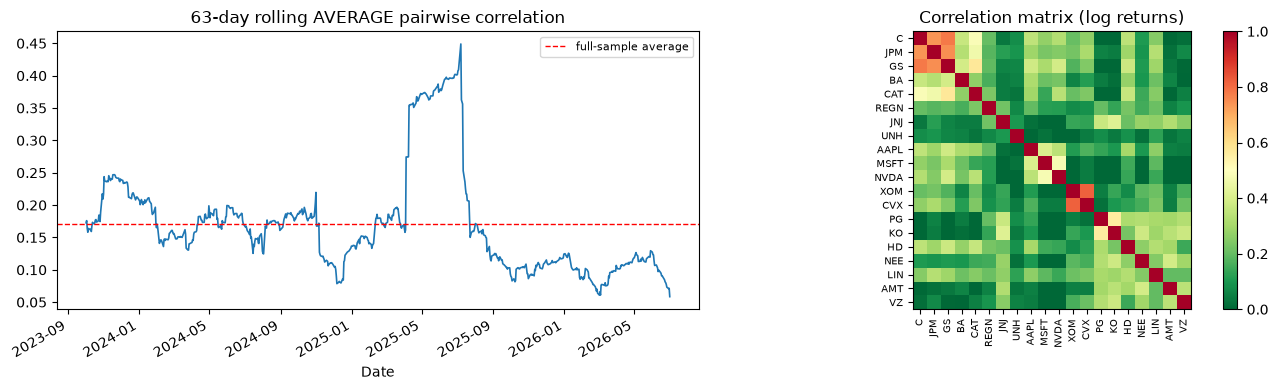

In [4]:
ann_vol = stk.std() * np.sqrt(252)
vt = pd.DataFrame({'sector': pd.Series(SECTOR), 'ann vol %': (ann_vol*100).round(1)})
print('Annualized volatility by name:')
print(vt.sort_values('ann vol %', ascending=False).to_string())

corr = stk.corr()
iu = np.triu_indices(N, 1)
pair = corr.values[iu]
print(f'\nPairwise correlations: {len(pair)} pairs | mean {pair.mean():.2f} | '
      f'median {np.median(pair):.2f} | min {pair.min():.2f} | max {pair.max():.2f}')

names = np.array(TICKERS)
hi = np.argmax(pair); lo = np.argmin(pair)
print('  tightest pair : %s-%s  %.2f' % (names[iu[0][hi]], names[iu[1][hi]], pair[hi]))
print('  loosest  pair : %s-%s  %.2f' % (names[iu[0][lo]], names[iu[1][lo]], pair[lo]))

sec = pd.Series(SECTOR)
block = corr.copy(); block.index = sec[corr.index].values; block.columns = sec[corr.columns].values
sec_corr = block.groupby(level=0).mean().T.groupby(level=0).mean()
print('\nAverage correlation by sector block:')
print(sec_corr.round(2).to_string())

port_vol = np.sqrt(W @ simple.cov().values @ W) * np.sqrt(252)  # simple: logs are not additive
wavg = ann_vol @ W
print(f'\nPortfolio vol: {port_vol:.1%}  vs  weighted-avg stock vol: {wavg:.1%}  '
      f'(diversification saves {wavg - port_vol:.1%})')
print(f'Diversification ratio (weighted-avg vol / portfolio vol): {wavg/port_vol:.2f}')

# Rolling AVERAGE pairwise correlation: the 3-stock version plotted 3 named pairs;
# with 190 pairs the informative object is the average and its dispersion.
def avg_pair_corr(window):
    c = window.corr().values
    return c[np.triu_indices(len(window.columns), 1)].mean()
roll_avg = pd.Series(
    [np.nan]*62 + [avg_pair_corr(stk.iloc[i-63:i]) for i in range(63, len(stk)+1)],
    index=stk.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roll_avg.plot(ax=axes[0], title='63-day rolling AVERAGE pairwise correlation', lw=1.2)
axes[0].axhline(pair.mean(), color='r', ls='--', lw=1, label='full-sample average')
axes[0].legend(fontsize=8)
im = axes[1].imshow(corr.values, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(TICKERS, rotation=90, fontsize=7)
axes[1].set_yticks(range(N)); axes[1].set_yticklabels(TICKERS, fontsize=7)
axes[1].set_title('Correlation matrix (log returns)')
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

Three things to read off. First, **volatility dispersion**: the range from the calmest staple or utility to the most volatile technology or aerospace name is wide, and it is what makes equal money weighting *not* equal risk weighting - the point risk parity makes formally in Part III.

Second, **the average pairwise correlation is far below the tightest pairs**. The sector-block matrix shows why: within-sector correlations (the diagonal blocks) run well above the off-diagonal cross-sector figures, so the diversification is coming from spanning sectors, not from holding twenty names. Twenty names in one sector would behave like one.

Third, **the diversification benefit is much larger than in the three-stock book**, because portfolio variance falls towards the average *covariance* as names are added while the weighted-average volatility does not. That gap is the entire economic case for the book. The rolling plot then supplies the caveat that governs everything after it: average correlation rises in stress windows, so the static number flatters calm periods and the diversification thins exactly when it is needed.

## 2b) Maximum drawdown and the risk limit
Lecture 1, Part B asks for daily returns, annualised volatility, Sharpe **and maximum drawdown**; Lecture 10's out-of-sample exercise asks for maximum drawdown alongside Sharpe. Drawdown is the statistic an investor actually feels, and it is the one volatility hides: two names with the same annualised volatility can have completely different peak-to-trough experiences depending on whether their bad days cluster.

**On the limit.** The course specifies that drawdown be *reported*; it does not state a numeric limit. The two thresholds used below are therefore an explicit governance assumption of my own, stated here so the breach test is reproducible rather than arbitrary: a **-30% single-name review trigger** and a tighter **-20% book-level limit**. The asymmetry is deliberate - a diversified book is expected to draw down less than its worst constituent, so a limit that binds equally on both would either be toothless at the name level or unmeetable at the book level.

Return, volatility, Sharpe and maximum drawdown (Lecture 1 Part B):
                  sector  ann ret %  ann vol %  Sharpe max drawdown    Calmar        peak      trough decline days   recovered recovery days current drawdown
UNH          Health Care      5.303     36.828   0.035    -0.613909  0.086388  2024-11-11  2025-08-01          179     not yet           NaN        -0.288834
REGN         Health Care      0.427     30.782  -0.116     -0.59692  0.007158  2024-08-27  2025-06-05          193     not yet           NaN        -0.475869
BA           Industrials      7.064     34.314   0.089    -0.483142  0.146209  2023-12-15  2025-04-04          325     not yet           NaN        -0.172891
NVDA           Info Tech     62.705     46.923   1.251     -0.36881  1.700188  2025-01-06  2025-04-04           61  2025-06-25            55        -0.160896
NEE            Utilities     11.733     27.316   0.283    -0.345696  0.339415  2023-07-21  2023-10-09           55  2024-05-09           147  

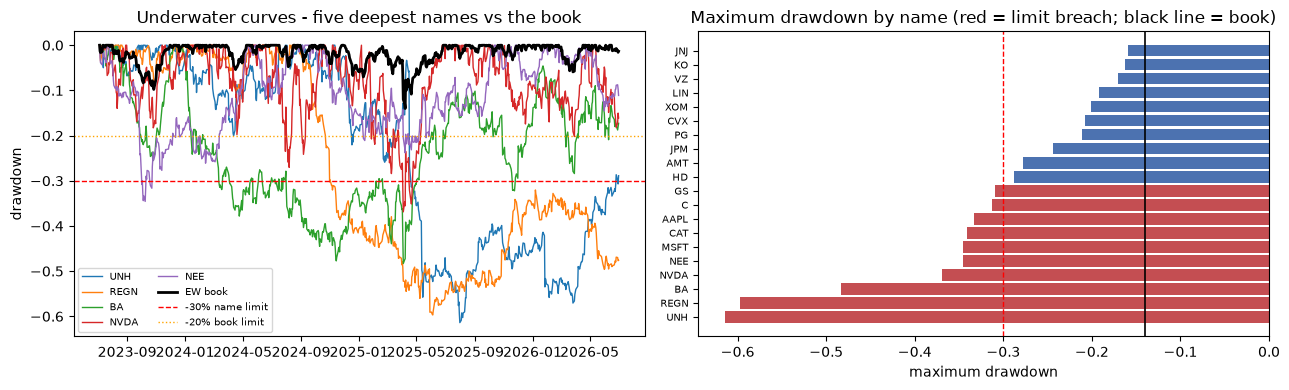

In [5]:
# Lecture 1 Part B: returns, annualised volatility, Sharpe, MAXIMUM DRAWDOWN.
# Drawdown is computed on the cumulative SIMPLE-return path - the wealth path an
# investor actually experiences. (Log returns would understate the depth.)
#
# LIMIT NOTE: the course asks for drawdown to be reported and sets no numeric limit.
# The two thresholds below are MY OWN stated governance assumption, not a course rule.
DD_LIMIT_NAME, DD_LIMIT_BOOK = -0.30, -0.20
RF_ANN = 0.04   # same 3M T-bill used in Part III, for the Sharpe column

def drawdown_path(r):
    """Underwater curve: cumulative wealth relative to its running peak."""
    eq = (1.0 + r).cumprod()
    return eq / eq.cummax() - 1.0

def dd_stats(r):
    """Depth, dates and duration of the single worst peak-to-trough episode.

    'decline days' and 'recovery days' are counted WITHIN that episode. A naive
    'days below the running peak' count is nearly the whole sample for any series
    that ends below its high, so it carries no information and is not reported.
    """
    dd     = drawdown_path(r)
    trough = dd.idxmin()
    peak   = (1.0 + r).cumprod().loc[:trough].idxmax()
    healed = dd.loc[trough:][dd.loc[trough:] >= -1e-9]
    recovered = healed.index[0] if len(healed) else None
    return {'max drawdown': float(dd.min()),
            'peak': peak.date(), 'trough': trough.date(),
            'decline days': int(r.index.get_loc(trough) - r.index.get_loc(peak)),
            'recovered': recovered.date() if recovered is not None else 'not yet',
            'recovery days': (int(r.index.get_loc(recovered) - r.index.get_loc(trough))
                              if recovered is not None else np.nan),
            'current drawdown': float(dd.iloc[-1])}

rows = {t: dd_stats(simple[t]) for t in TICKERS}
rows['EW BOOK'] = dd_stats(port)
dd_tbl = pd.DataFrame(rows).T
dd_tbl.insert(0, 'sector', pd.Series(SECTOR).reindex(dd_tbl.index).fillna('-- portfolio --'))
dd_tbl['ann ret %']  = [ (simple[t].mean()*252*100 if t in TICKERS else port.mean()*252*100)
                         for t in dd_tbl.index ]
dd_tbl['ann vol %']  = [ (simple[t].std()*np.sqrt(252)*100 if t in TICKERS
                          else port.std()*np.sqrt(252)*100) for t in dd_tbl.index ]
dd_tbl['Sharpe']     = (dd_tbl['ann ret %']/100 - RF_ANN) / (dd_tbl['ann vol %']/100)
dd_tbl['Calmar']     = (dd_tbl['ann ret %']/100) / dd_tbl['max drawdown'].abs()

show = ['sector','ann ret %','ann vol %','Sharpe','max drawdown','Calmar',
        'peak','trough','decline days','recovered','recovery days','current drawdown']
print('Return, volatility, Sharpe and maximum drawdown (Lecture 1 Part B):')
print(dd_tbl[show].sort_values('max drawdown').round(3).to_string())

# ---- Limit test ----------------------------------------------------------------
names_dd = dd_tbl.loc[TICKERS, 'max drawdown'].astype(float)
book_dd  = float(dd_tbl.loc['EW BOOK', 'max drawdown'])
breach   = names_dd[names_dd < DD_LIMIT_NAME].sort_values()

print('\n' + '='*72)
print('DRAWDOWN LIMIT TEST   single name {:.0%} | book {:.0%}   (stated assumption, not a course rule)'
      .format(DD_LIMIT_NAME, DD_LIMIT_BOOK))
print('='*72)
if len(breach):
    print('BREACH - {} of {} names exceed the {:.0%} single-name limit:'
          .format(len(breach), N, DD_LIMIT_NAME))
    for t, v in breach.items():
        st = dd_tbl.loc[t]
        rec = ('recovered {} ({} days)'.format(st['recovered'], int(st['recovery days']))
               if st['recovered'] != 'not yet' else 'NOT RECOVERED')
        print('   {:<5} {:>7.1%}   {} -> {} ({} days down)   {}'
              .format(t, v, st['peak'], st['trough'], st['decline days'], rec))
else:
    print('No single name breaches the {:.0%} limit.'.format(DD_LIMIT_NAME))

print('\nEqual-weight book: {:.1%} max drawdown vs a {:.0%} limit -> {}'
      .format(book_dd, DD_LIMIT_BOOK,
              'BREACH' if book_dd < DD_LIMIT_BOOK else 'within limit'))
print('Worst single name {:.1%} ({}) vs the book {:.1%}: diversification absorbed {:.1f}pp '
      'of the worst constituent\'s peak-to-trough.'
      .format(names_dd.min(), names_dd.idxmin(), book_dd,
              (book_dd - names_dd.min())*100))
still = dd_tbl.loc[TICKERS,'current drawdown'].astype(float)
print('Names more than 10% below their own peak at the end of the window: {} of {}  {}'
      .format(int((still < -0.10).sum()), N,
              list(still[still < -0.10].sort_values().index)))
unrec = [t for t in breach.index if dd_tbl.loc[t,'recovered'] == 'not yet']
print('Breaching names that never recovered: {} of {}  {}'
      .format(len(unrec), len(breach), unrec if unrec else ''))

# ---- Underwater chart ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
worst5 = names_dd.nsmallest(5).index
for t in worst5:
    axes[0].plot(drawdown_path(simple[t]), lw=1, label=t)
axes[0].plot(drawdown_path(port), lw=2, color='k', label='EW book')
axes[0].axhline(DD_LIMIT_NAME, color='r', ls='--', lw=1,
                label='{:.0%} name limit'.format(DD_LIMIT_NAME))
axes[0].axhline(DD_LIMIT_BOOK, color='orange', ls=':', lw=1,
                label='{:.0%} book limit'.format(DD_LIMIT_BOOK))
axes[0].set_title('Underwater curves - five deepest names vs the book')
axes[0].set_ylabel('drawdown'); axes[0].legend(fontsize=7, ncols=2)

order = names_dd.sort_values()
cols = ['#c44e52' if v < DD_LIMIT_NAME else '#4c72b0' for v in order]
axes[1].barh(range(len(order)), order.values, color=cols)
axes[1].axvline(DD_LIMIT_NAME, color='r', ls='--', lw=1)
axes[1].axvline(book_dd, color='k', ls='-', lw=1.2)
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order.index, fontsize=7)
axes[1].set_xlabel('maximum drawdown')
axes[1].set_title('Maximum drawdown by name (red = limit breach; black line = book)')
plt.tight_layout(); plt.show()

Three things to take from this, and the first is the reason the section exists.

**Volatility and drawdown rank the book differently.** A name can carry moderate annualised volatility and still post the deepest peak-to-trough loss, because drawdown is a *path* statistic: it depends on whether the bad days arrive together. Sorting by maximum drawdown rather than by volatility reorders the table, and any name whose drawdown rank is far worse than its volatility rank is one whose losses cluster - exactly the property a single volatility number is designed not to show. The Calmar ratio (return per unit of drawdown) is the same point expressed as a reward-to-pain measure, and it will disagree with the Sharpe ratio for the same names.

**The limit breaches are the reportable result.** Every breaching name is listed with its peak date, trough date, time underwater and whether it has recovered - which is the form a risk committee would actually want, because the recovery column separates a sharp shock that mean-reverted from a structural repricing the position never came back from. A name still underwater at the end of the window has not had its loss reversed by the market; it has simply stopped falling.

**The book absorbs far less than you might hope.** The equal-weight book's maximum drawdown is much shallower than its worst constituent's, and the gap is what diversification bought. But note that the book's drawdown is *not* the average of the names' drawdowns and is much worse than 1/20 of the worst: individual troughs occur on different dates, so they partly offset, but the systematic component is common to all twenty and no amount of diversification removes it. That residual is the same systematic risk the beta and CoVaR sections measure, seen here as a wealth path instead of a variance.

## 3) Beta, heavy tails and volatility clustering
Clustering is tested **per name** (it is not uniform): an ARCH-LM test and Ljung-Box on squared returns, plus the first-order autocorrelation of returns against squared returns. With 20 names the table is sorted and summarised rather than discussed name by name.

             sector   beta  R2(systematic)   skew  excess kurt  AC1(r)  AC1(r^2)  LB(r^2) p  ARCH-LM p  JB p
NVDA      Info Tech  2.106           0.454 -0.084        4.800  -0.079     0.117      0.005      0.051   0.0
GS       Financials  1.337           0.495  0.172        6.837   0.018     0.159      0.000      0.000   0.0
CAT     Industrials  1.286           0.370  0.296        4.179  -0.020     0.077      0.001      0.002   0.0
C        Financials  1.235           0.417 -0.509        5.899   0.070     0.185      0.000      0.000   0.0
AAPL      Info Tech  1.119           0.410  0.362       10.272   0.042     0.226      0.000      0.000   0.0
BA      Industrials  1.070           0.219  0.021        5.201   0.027     0.102      0.000      0.000   0.0
MSFT      Info Tech  0.977           0.357 -0.247        6.165  -0.003     0.017      0.010      0.037   0.0
JPM      Financials  0.886           0.335 -0.178        8.090  -0.013     0.173      0.000      0.000   0.0
HD        Cons Disc

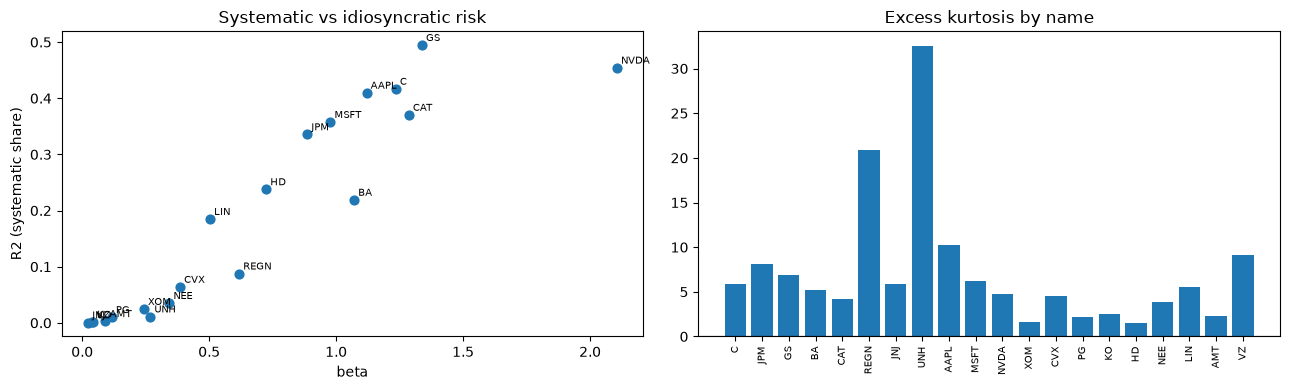

In [6]:
rows = []
for t in TICKERS:
    b, a, r, p, se = stats.linregress(mkt, stk[t])
    lb_sq = acorr_ljungbox(stk[t]**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    jb    = stats.jarque_bera(stk[t]).pvalue
    arch  = het_arch(stk[t], nlags=10)[1]
    rows.append([SECTOR[t], b, r**2, stk[t].skew(), stk[t].kurtosis(),
                 stk[t].autocorr(1), (stk[t]**2).autocorr(1), lb_sq, arch, jb])
tbl = pd.DataFrame(rows, index=TICKERS,
    columns=['sector','beta','R2(systematic)','skew','excess kurt','AC1(r)','AC1(r^2)',
             'LB(r^2) p','ARCH-LM p','JB p'])
print(tbl.sort_values('beta', ascending=False).round(3).to_string())

print('\nSummary across the cross-section:')
print('  beta            : min %.2f (%s)  max %.2f (%s)  mean %.2f'
      % (tbl['beta'].min(), tbl['beta'].idxmin(), tbl['beta'].max(), tbl['beta'].idxmax(),
         tbl['beta'].mean()))
print('  R2 systematic   : min %.2f (%s)  max %.2f (%s)'
      % (tbl['R2(systematic)'].min(), tbl['R2(systematic)'].idxmin(),
         tbl['R2(systematic)'].max(), tbl['R2(systematic)'].idxmax()))
print('  excess kurtosis : min %.1f  max %.1f (%s)'
      % (tbl['excess kurt'].min(), tbl['excess kurt'].max(), tbl['excess kurt'].idxmax()))
print('  reject normality (JB p<0.01)      : %d of %d names' % ((tbl['JB p']<0.01).sum(), N))
print('  reject no-ARCH  (ARCH-LM p<0.01)  : %d of %d names' % ((tbl['ARCH-LM p']<0.01).sum(), N))
print('  reject LB on r^2 (p<0.01)         : %d of %d names' % ((tbl['LB(r^2) p']<0.01).sum(), N))

# Jump vs clustering: a name whose kurtosis collapses when its single worst day is
# removed has JUMP risk; one whose kurtosis survives has genuine fat conditional tails.
jump = {}
for t in TICKERS:
    s = stk[t]; worst = s.abs().idxmax()
    jump[t] = [s.kurtosis(), s.drop(worst).kurtosis(), worst.strftime('%Y-%m-%d')]
jt = pd.DataFrame(jump, index=['excess kurt','ex-worst-day','worst day']).T
jt['drop %'] = (1 - jt['ex-worst-day'].astype(float)/jt['excess kurt'].astype(float))*100
print('\nJump diagnostic - kurtosis with and without each name\'s single worst day:')
print(jt.sort_values('drop %', ascending=False).head(8).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(tbl['beta'], tbl['R2(systematic)'], s=40)
for t in TICKERS:
    axes[0].annotate(t, (tbl.loc[t,'beta'], tbl.loc[t,'R2(systematic)']), fontsize=7,
                     xytext=(3,3), textcoords='offset points')
axes[0].set_xlabel('beta'); axes[0].set_ylabel('R2 (systematic share)')
axes[0].set_title('Systematic vs idiosyncratic risk')
axes[1].bar(range(N), tbl.loc[TICKERS,'excess kurt'].values)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(TICKERS, rotation=90, fontsize=7)
axes[1].set_title('Excess kurtosis by name'); axes[1].axhline(0, color='k', lw=.8)
plt.tight_layout(); plt.show()

A blanket 'fat tails and clustering' would be wrong here, and the cross-section shows why. **Beta and systematic share vary widely**: the high-beta financials and cyclicals carry a large systematic component, while the defensive staples, utilities and health-care names sit low on both axes - which is exactly the spread that makes the book diversify, and the same ordering that will drive the CoVaR ranking in Part III.

Normality is rejected essentially everywhere, but the **source** of the non-normality differs by name and that distinction decides which model to use. The ARCH-LM and Ljung-Box columns identify genuine volatility **clustering** - slowly decaying autocorrelation in squared returns with none in returns - which is what GARCH is built for. The jump diagnostic identifies the opposite pattern: names whose excess kurtosis collapses once a single day is removed have **jump** risk, not clustering, and fitting GARCH to them would model the wrong thing. The next section picks the GARCH name by test rather than by volatility for precisely this reason.

## 4) 1-day 99% VaR by three methods
To be three *different* methods, Monte Carlo must not draw from the same normal the parametric method assumes (that only reproduces it). MC here uses a **variance-matched Student-t** (nu=5, scaled by (nu-2)/nu so only the tail shape differs from parametric). The covariance is now 20x20, so the Cholesky factor is checked for positive-definiteness before it is used.

In [7]:
z99 = stats.norm.ppf(1 - ALPHA)
mu, cov = simple.mean().values, simple.cov().values
sig_p = np.sqrt(W @ cov @ W)

var_param = -(W @ mu + z99 * sig_p) * V0
var_hist  = -np.percentile(port, (1 - ALPHA) * 100) * V0

# With 20 assets and ~750 observations the sample covariance is estimable (T >> N) but
# check conditioning before factorising - this is the step that silently fails at scale.
eig = np.linalg.eigvalsh(cov)
print('Covariance check: %dx%d, smallest eigenvalue %.3e, condition number %.1f'
      % (N, N, eig.min(), eig.max()/eig.min()))
assert eig.min() > 0, 'sample covariance not positive definite - shrink before factorising'

# variance-matched multivariate t: fat tails, same covariance as parametric
NU, NSIM = 5, 200_000
Lchol = np.linalg.cholesky((NU - 2) / NU * cov)
zt = rng.standard_normal((NSIM, N)) @ Lchol.T
gt = rng.chisquare(NU, NSIM) / NU
sim = mu + zt / np.sqrt(gt)[:, None]
sim_port = sim @ W
var_mc = -np.quantile(sim_port, 1 - ALPHA) * V0

vars_ = pd.Series({'Parametric (normal)': var_param,
                   'Historical': var_hist,
                   'Monte Carlo (t, nu=5)': var_mc})
print()
print(vars_.round(0).astype(int).to_string())
print(f'\nSpread: {vars_.max()-vars_.min():,.0f} USD '
      f'({vars_.max()/vars_.min()-1:.0%} of the smallest).  '
      f'MC sd {sim_port.std():.4%} vs sample {port.std():.4%} (variance matched).')
print(f'VaR as % of book: ' +
      '  '.join(f'{k} {v/V0:.2%}' for k, v in vars_.items()))

Covariance check: 20x20, smallest eigenvalue 3.458e-05, condition number 45.4

Parametric (normal)      16916
Historical               17106
Monte Carlo (t, nu=5)    18974

Spread: 2,059 USD (12% of the smallest).  MC sd 0.7567% vs sample 0.7600% (variance matched).
VaR as % of book: Parametric (normal) 1.69%  Historical 1.71%  Monte Carlo (t, nu=5) 1.90%


The three methods use the same data and the same confidence level and still disagree, and the size of that disagreement is the size of the modelling choice. A *normal* Monte Carlo would have reproduced the parametric number by construction; the variance-matched t sits apart from it only because of tail shape, which is the whole point of running it.

Two effects specific to the 20-name book are worth noting against the three-stock version. First, **VaR as a share of the book is much smaller**, because portfolio volatility has fallen towards the average covariance. Second, **the gap between historical and parametric narrows**: with three names a single stock's jump moved the portfolio quantile directly, whereas at 1/20 weight one name's gap contributes a twentieth as much, so the empirical tail is closer to Gaussian. Diversification does not only reduce volatility - it also pulls the portfolio distribution towards normality, which is the central limit theorem operating on the book. The residual gap is what idiosyncratic tail risk survives that averaging.

## 5) Expected Shortfall & VaR super-additivity
Super-additivity is checked **weight-consistently** - each name's VaR at its *portfolio weight* against the weighted-portfolio VaR - and across two confidence levels, not as a single headline.

In [8]:
def var_es_sample(r, alpha=ALPHA):
    q = np.percentile(r, (1 - alpha) * 100)
    return -q * V0, -r[r <= q].mean() * V0

es_param = -(W @ mu - sig_p * stats.norm.pdf(z99) / (1 - ALPHA)) * V0
es_hist  = var_es_sample(port)[1]
es_mc    = -sim_port[sim_port <= np.quantile(sim_port, 1 - ALPHA)].mean() * V0
es_tbl = pd.DataFrame({'VaR': vars_.values, 'ES': [es_param, es_hist, es_mc]},
                      index=vars_.index)
es_tbl['ES / VaR - 1'] = (es_tbl['ES']/es_tbl['VaR'] - 1).map('{:.1%}'.format)
print(es_tbl.round(0).to_string())

print(f'\nWeight-consistent super-additivity check (each name at weight 1/{N}):')
for a in (0.95, 0.99):
    ind = sum(var_es_sample(W[i] * simple[t], a)[0] for i, t in enumerate(TICKERS))
    pv  = var_es_sample(port, a)[0]
    print(f'  {a:.0%}: sum standalone {ind:,.0f}  vs  portfolio {pv:,.0f}  '
          f'-> super-additive? {pv > ind}  (diversification benefit {ind-pv:,.0f}, '
          f'{1-pv/ind:.0%} of the standalone sum)')

# Component (Euler) VaR: which names actually carry the parametric VaR?
# VaR = -(W'mu + z*sigma_p)*V0 is homogeneous of degree 1 in W, so Euler's theorem
# allocates it exactly - PROVIDED the drift term is allocated as well as the risk term.
mvar   = -(mu + z99 * (cov @ W) / sig_p)   # marginal VaR per unit weight, incl. drift
cvar_i = W * mvar * V0                     # component VaR, sums to parametric VaR
comp = pd.DataFrame({'sector': pd.Series(SECTOR), 'component VaR $': cvar_i,
                     '% of VaR': cvar_i/cvar_i.sum()*100}, index=TICKERS)
print('\nEuler decomposition of the parametric VaR (components sum to total):')
print(comp.sort_values('% of VaR', ascending=False).round(2).to_string())
print('  check: components sum to ${:,.0f} vs parametric VaR ${:,.0f}'
      .format(cvar_i.sum(), var_param))

                           VaR       ES ES / VaR - 1
Parametric (normal)    16916.0  19491.0        15.2%
Historical             17106.0  27571.0        61.2%
Monte Carlo (t, nu=5)  18974.0  25027.0        31.9%

Weight-consistent super-additivity check (each name at weight 1/20):
  95%: sum standalone 24,129  vs  portfolio 10,545  -> super-additive? False  (diversification benefit 13,584, 56% of the standalone sum)
  99%: sum standalone 43,235  vs  portfolio 17,106  -> super-additive? False  (diversification benefit 26,129, 60% of the standalone sum)

Euler decomposition of the parametric VaR (components sum to total):
             sector  component VaR $  % of VaR
GS       Financials          1397.95      8.26
C        Financials          1329.41      7.86
NVDA      Info Tech          1321.04      7.81
CAT     Industrials          1285.38      7.60
BA      Industrials          1266.11      7.48
JPM      Financials          1041.40      6.16
AAPL      Info Tech          1028.92      6

ES exceeds VaR at every method, and the gap widens with the fatness of the assumed tail - the historical and t-based figures run well above their VaR, the normal-based parametric figure barely above it. That gap is exactly the severity information VaR discards.

VaR is **sub-additive** here at both confidence levels, and the diversification benefit is far larger than in the three-stock book because there are twenty partly-independent tails to average rather than three. That is a consequence of the sample correlations, not a guarantee: VaR is not a coherent risk measure and can fail sub-additivity, which is why Basel FRTB replaced 99% VaR with 97.5% ES, a measure that is sub-additive by construction.

The **Euler decomposition** is the exhibit that only becomes useful at this scale. Equal money weights do not produce equal risk contributions: the high-beta, high-volatility names carry a disproportionate share of the VaR, and the defensive names carry less than their 5% of capital. Reading component VaR is how a risk manager sets position limits, and it is the same arithmetic risk parity solves in Part III.

## 6) GARCH(1,1) - stock chosen by a clustering test
The GARCH name is picked because a test *finds* ARCH effects in it, not because it is the most volatile. The fit is then checked: parameter significance, a normal-vs-t AIC comparison, and the persistence edge case.

Clustering ranking (ARCH-LM statistic, higher = stronger clustering):
      ARCH-LM stat  ann vol %  excess kurt
CVX         143.89      22.82         4.56
AAPL        104.22      26.20        10.27
LIN          90.98      17.52         5.55
XOM          76.76      23.26         1.61
C            69.27      28.66         5.90
BA           58.04      34.27         5.20
GS           54.58      28.49         6.84
NEE          36.15      27.43         3.84
JPM          33.02      22.91         8.09
CAT          27.51      31.66         4.18
KO           19.88      15.76         2.47
MSFT         19.26      24.48         6.16
NVDA         18.24      46.80         4.80
PG           14.44      17.55         2.18
HD           13.74      22.26         1.52
JNJ          13.01      17.78         5.92
AMT           8.93      26.08         2.31
VZ            8.43      23.19         9.17
UNH           4.37      38.13        32.54
REGN          1.33      31.26        20.88

-> GARCH on CVX (strongest

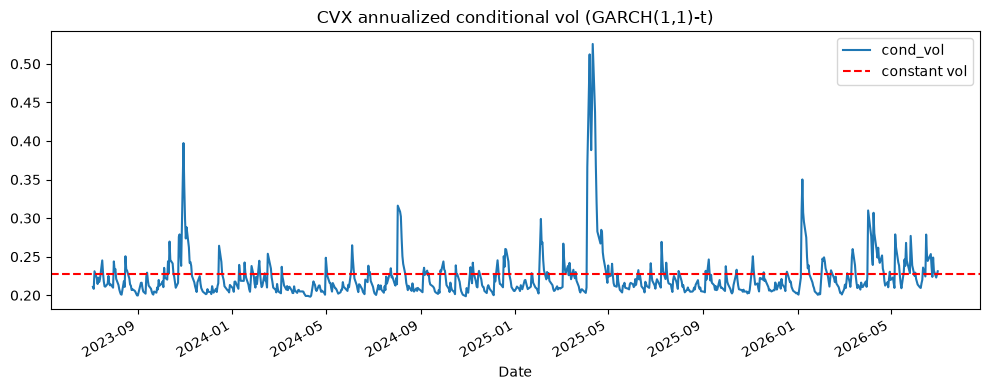

In [9]:
arch_lm = pd.Series({t: het_arch(stk[t], nlags=10)[0] for t in TICKERS})
rank = pd.DataFrame({'ARCH-LM stat': arch_lm, 'ann vol %': ann_vol*100,
                     'excess kurt': tbl['excess kurt']}).sort_values('ARCH-LM stat', ascending=False)
print('Clustering ranking (ARCH-LM statistic, higher = stronger clustering):')
print(rank.round(2).to_string())

GST = arch_lm.idxmax()
vol_leader = ann_vol.idxmax()
print(f'\n-> GARCH on {GST} (strongest ARCH effect).')
if vol_leader != GST:
    print(f'   Note: the most VOLATILE name is {vol_leader} ({ann_vol[vol_leader]:.1%}), not {GST}. '
          f'Choosing on volatility would fit a clustering model to whichever name happens to '
          f'move most, which for a jump-driven name is the wrong model.')

from arch import arch_model
res  = arch_model(stk[GST]*100, vol='Garch', p=1, q=1, dist='t').fit(disp='off')
resn = arch_model(stk[GST]*100, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
al, be, om = res.params['alpha[1]'], res.params['beta[1]'], res.params['omega']
persist = al + be
print(); print(res.params.round(4).to_string())
print('\nparameter p-values:', {k: round(v,4) for k,v in res.pvalues.items()})
print(f'Persistence alpha+beta = {persist:.3f}   AIC: t={res.aic:.0f} vs normal={resn.aic:.0f} '
      f"-> {'Student-t' if res.aic<resn.aic else 'normal'} preferred")

if persist < 1:
    print(f'long-run vol = {np.sqrt(om/(1-persist))/100*np.sqrt(252):.1%} annual; '
          f'half-life = {np.log(0.5)/np.log(persist):.1f} days')
else:
    print('Persistence >= 1: near-integrated (IGARCH) fit - long-run variance undefined, investigate.')

sig_fc  = np.sqrt(res.forecast(horizon=1).variance.iloc[-1,0]) / 100
sig_con = stk[GST].std()
print(f'\n1-day-ahead conditional vol {sig_fc:.2%} vs unconditional {sig_con:.2%}')
print(f'GARCH-t 99% VaR {(-(z99*sig_fc)*V0):,.0f}  vs constant-vol VaR {(-(z99*sig_con)*V0):,.0f} '
      f'({GST}-only, $1m)')

(res.conditional_volatility/100*np.sqrt(252)).plot(title=f'{GST} annualized conditional vol (GARCH(1,1)-t)')
plt.axhline(sig_con*np.sqrt(252), color='r', ls='--', label='constant vol'); plt.legend(); plt.tight_layout(); plt.show()

The ARCH-LM ranking, not the volatility ranking, selects the name - and the two need not agree. A name can be the most volatile in the book because of a handful of jumps while showing little conditional-variance persistence, and fitting GARCH to it would be modelling jump risk with a clustering model.

Read the fit on three checks. **Persistence** below 1 gives a stable model with a defined long-run variance and a finite half-life; a value at or above 1 is the near-integrated case where long-run variance is undefined and the model should not be used for term-structure forecasts. **Student-t against normal on AIC** tests whether the conditional tails are fat once clustering is removed. **Parameter significance** matters for interpretation: if beta is strongly significant and alpha only marginally so, the conditional variance is driven by persistence rather than by fresh news, and alpha should not be read as if it were solid.

Whether the one-day-ahead conditional volatility sits above or below the unconditional figure depends on where the window ends. A conditional model that tightens capital in calm periods and raises it after a shock is doing its job; the direction on any single day is not evidence for or against the model.

## 7) Backtesting VaR - Basel traffic light + Kupiec
The zone is read on **250 observations** (the thresholds are calibrated for that), and the count is backed by a Kupiec test, breach timing, and the full-sample rate - the count alone has little power.

Recent 250d: 0 exceptions (expected 2.5) -> GREEN zone
Kupiec LR=5.03, p=0.025  (REJECTS correct coverage)
breaches: []
Full sample: 9/501 = 1.80% exceptions vs 1.00% expected
Worst 250d window in sample: 9 exceptions -> YELLOW zone
Christoffersen independence (full sample): LR=2.13, p=0.144  (transitions 00=483 01=8 10=8 11=1)


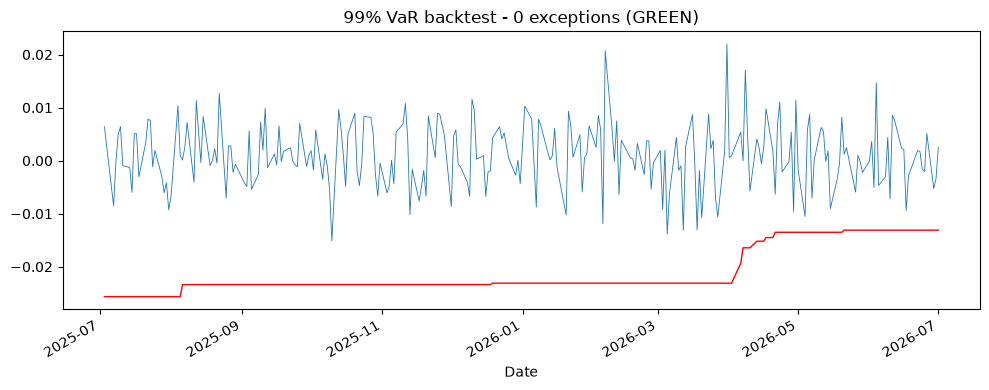

In [10]:
WIN = 250
var_roll = -port.rolling(WIN).quantile(1 - ALPHA)
bt = pd.DataFrame({'r': port, 'VaR': var_roll.shift(1)}).dropna()
recent = bt.tail(250)
exc = recent['r'] < -recent['VaR']
n, T, p = int(exc.sum()), len(recent), 1 - ALPHA
zone = 'GREEN' if n <= 4 else 'YELLOW' if n <= 9 else 'RED'

if n == 0:
    LR = -2 * T * np.log(1 - p)
else:
    LR = -2*((T-n)*np.log(1-p)+n*np.log(p)-((T-n)*np.log(1-n/T)+n*np.log(n/T)))
kp = 1 - stats.chi2.cdf(LR, 1)

excf = bt['r'] < -bt['VaR']; nf = int(excf.sum())
brk = list(recent.index[exc].strftime('%Y-%m-%d'))
print(f'Recent 250d: {n} exceptions (expected {T*p:.1f}) -> {zone} zone')
print(f'Kupiec LR={LR:.2f}, p={kp:.3f}  ({"cannot reject" if kp>0.05 else "REJECTS"} correct coverage)')
print(f'breaches: {brk}')
print(f'Full sample: {nf}/{len(bt)} = {nf/len(bt):.2%} exceptions vs 1.00% expected')
wr = int(excf.rolling(WIN).sum().max())
wzone = 'GREEN' if wr <= 4 else 'YELLOW' if wr <= 9 else 'RED'
print(f'Worst {WIN}d window in sample: {wr} exceptions -> {wzone} zone')

# Christoffersen independence test: are breaches clustered? (needs n >= 2 to be defined)
b = excf.astype(int).values
n00 = int(((b[:-1]==0)&(b[1:]==0)).sum()); n01 = int(((b[:-1]==0)&(b[1:]==1)).sum())
n10 = int(((b[:-1]==1)&(b[1:]==0)).sum()); n11 = int(((b[:-1]==1)&(b[1:]==1)).sum())
if n01+n11 > 0 and n00+n01 > 0 and n10+n11 > 0:
    pi  = (n01+n11)/(n00+n01+n10+n11)
    pi0 = n01/(n00+n01); pi1 = n11/(n10+n11) if (n10+n11) else 0.0
    def ll(a, k, m): return k*np.log(a) + m*np.log(1-a) if 0 < a < 1 else 0.0
    LRind = -2*((ll(pi,n01+n11,n00+n10)) - (ll(pi0,n01,n00) + ll(pi1,n11,n10)))
    print(f'Christoffersen independence (full sample): LR={LRind:.2f}, '
          f'p={1-stats.chi2.cdf(LRind,1):.3f}  '
          f'(transitions 00={n00} 01={n01} 10={n10} 11={n11})')
else:
    print('Christoffersen independence: too few breaches for the test to be defined.')

ax = recent['r'].plot(lw=.6, title=f'99% VaR backtest - {n} exceptions ({zone})')
(-recent['VaR']).plot(ax=ax, color='r', lw=1)
ax.scatter(recent.index[exc], recent['r'][exc], color='k', zorder=5); plt.tight_layout(); plt.show()

Read the zone with three qualifications, all of which the output supplies.

**Power, and the direction of any rejection.** At 99% only about 2.5 breaches are expected in 250 days, so Kupiec has almost no power over a single year: failing to reject correct coverage is weak evidence, not a good model. Note also that Kupiec is two-sided. It rejects for **too few** exceptions as readily as for too many - zero breaches in 250 days is itself far enough from 2.5 to reject at 5%. That is not the same failure as excessive breaches: a model that is systematically too conservative ties up capital rather than understating risk, so a supervisor reads it very differently from a red-zone count even though the test statistic looks similar. Always state which side of the expected count the rejection came from.

**Window dependence.** The recent-250-day zone and the full-sample exception rate can point in opposite directions, and the worst 250-day window in the sample is the honest stress read. Historical VaR responds to the composition of its trailing window rather than to current conditions, so a green count on a quiet window can sit on top of a materially worse full-sample rate.

**Independence.** The Christoffersen test asks whether breaches arrive in clusters, which is the failure mode that matters - a model can have the right *number* of exceptions and still deliver them all in one week. With a 20-name book there are more breaches over the full sample than a three-stock book generated, so this test is better identified here than it was there; the count alone remains the weakest of the three diagnostics.

## Sanity checks - could every headline number be real?
The single most valuable habit: before writing about a figure, check its size is even possible. Each headline number is validated against a plausible range; anything outside is flagged to investigate, not reported. With 20 names the per-name checks are aggregated to a pass count so a single failure is still visible.

In [11]:
checks = ([(f'{t} ann. vol %', ann_vol[t]*100, 10, 70) for t in TICKERS] +
          [(f'{t} beta', tbl.loc[t, 'beta'], 0.0, 2.5) for t in TICKERS] +
          [(f'{t} max drawdown', dd_tbl.loc[t,'max drawdown'], -0.95, 0.0) for t in TICKERS] +
          [('Portfolio ann. vol %', port_vol*100, 8, 40),
           ('Book max drawdown', book_dd, -0.60, 0.0),
           ('Avg pairwise correlation', pair.mean(), 0.0, 0.9),
           ('Parametric VaR % book', var_param/V0*100, 0.5, 5.0),
           ('Historical VaR % book', var_hist/V0*100, 0.5, 5.0),
           ('Monte Carlo VaR % book', var_mc/V0*100, 0.5, 5.0),
           ('GARCH persistence', persist, 0.0, 0.999)])

fails = [(nm, v, lo, hi) for nm, v, lo, hi in checks if not (lo <= v <= hi)]
per_name_checks = 3*N
print(f'{per_name_checks} per-name checks + {len(checks)-per_name_checks} portfolio checks '
      f'= {len(checks)} total')
print(f"{'quantity':26s}{'value':>10s}   plausible   status")
for nm, v, lo, hi in checks[per_name_checks:]:
    ok = lo <= v <= hi
    print(f'{nm:26s}{v:>10.2f}   [{lo}, {hi}]   {"OK" if ok else "FLAG - investigate"}')
print()
if fails:
    print('FLAGGED - investigate before reporting:')
    for nm, v, lo, hi in fails:
        print(f'  {nm:26s}{v:>10.2f}   outside [{lo}, {hi}]')
else:
    print('All %d headline numbers within plausible ranges.' % len(checks))

60 per-name checks + 7 portfolio checks = 67 total
quantity                       value   plausible   status
Portfolio ann. vol %           12.07   [8, 40]   OK
Book max drawdown              -0.14   [-0.6, 0.0]   OK
Avg pairwise correlation        0.17   [0.0, 0.9]   OK
Parametric VaR % book           1.69   [0.5, 5.0]   OK
Historical VaR % book           1.71   [0.5, 5.0]   OK
Monte Carlo VaR % book          1.90   [0.5, 5.0]   OK
GARCH persistence               0.73   [0.0, 0.999]   OK

All 67 headline numbers within plausible ranges.


## 8) Discussion
**Assumptions.** Parametric and (implicitly) Monte Carlo VaR assume a fixed parametric shape for returns, which the task-3 evidence contradicts for a large share of the book. Historical VaR assumes the last three years resemble tomorrow: the window contains the stresses it contains and no 2008- or 2020-scale crash. All three methods assume liquidation at observed prices and so ignore liquidity, which Part II prices explicitly. The 20x20 covariance is estimated from roughly 750 observations, so it is well identified here - but the ratio of parameters to data (190 distinct covariances) is the constraint that would bind on a larger book, and it is why Part III shrinks it.

**Strengths.** VaR compresses a twenty-asset book into one auditable number for limits and capital, and the Euler decomposition then attributes that number back to individual names, which is what makes it usable for position limits rather than only for reporting. ES adds the tail severity VaR discards and is sub-additive by construction. The GARCH-t fit captures the conditional-volatility dynamics an ARCH-LM test actually found, on the name where that test found them.

**Limitations.** The spread across the three VaR methods is the size of the modelling choice, and it does not shrink with more names - only its share of the book does. The three-year window is regime-dependent, as the gap between the recent-window zone and the full-sample exception rate shows. A 99% one-day quantile is silent on magnitude beyond the threshold; ES helps but rests on few tail observations. And none of these anticipate structural breaks - a grounding, a failed trial, a credit or litigation event - which arrive as jumps rather than as draws from an estimated tail.

**Real-world implications.** Diversifying across twenty names and eleven sectors removes a great deal of idiosyncratic risk, and the component-VaR table shows exactly where the residual sits: concentrated in the high-beta, high-volatility names, not spread evenly across the book. What it does **not** remove is the systematic component, and the rolling-correlation plot shows that component growing in stress. A risk manager would therefore pair VaR and ES limits with component-VaR position limits, named single-name stress tests for the jump-prone holdings, and a correlation monitor - because the number that matters in a crisis is not the calm-period VaR but the one computed with correlations at their stressed levels, which is what Part III's stress section builds.

---
# Part II - Credit, Derivative, Liquidity and Operational Risk
The risks market risk misses, on the same firms and window: Merton PD, a loan book under a Gaussian and a Student-t copula, option Greeks and option VaR, liquidity-adjusted VaR, and a Poisson-lognormal operational loss distribution. Equity volatilities are Part I's.

Twenty obligors change one method. The three-stock version enumerated all 2^3 = 8 default outcomes exactly; 2^20 = 1,048,576 outcomes is both impractical and unnecessary, so the loss distribution is built by the same conditional-independence argument summed by **recursion on a loss grid** instead of by enumeration. It remains exact up to the grid width, which is reported. The single-factor model, the Gauss-Hermite integration over the factor, the Student-t copula stress and the Vasicek/Basel comparison are all unchanged.

In [12]:
from scipy.stats import norm, t as tdist
from scipy.optimize import fsolve
np.random.seed(SEED)

px, vol = PX[TICKERS], VOL

ret = np.log(px / px.shift(1)).dropna()
sigma_E = ret.std() * np.sqrt(252)
print('Fixed window %s .. %s  (%d obs)' % (px.index[0].date(), px.index[-1].date(), len(px)))

# Equity E and debt D are fixed constants as of AS_OF_DATE, not fetched: market cap is
# itself rolling, and the Merton solve needs one pinned debt face. E is market
# capitalisation; D is total borrowings (long-term debt plus short-term/wholesale
# funding) of the order reported near AS_OF_DATE.
#
# SOURCE NOTE - READ BEFORE QUOTING ANY NUMBER BELOW. These are HAND-ENTERED
# order-of-magnitude figures, not a live filings pull. They are entered to exercise the
# Merton solve and to set relative leverage across the book; they are not audited
# balance-sheet values. For the three banks D is a judgement figure rather than a single
# reported line: deposits make a one-year zero-coupon debt face ill-defined for a bank,
# which is the approximation discussed under task 1.
cap = {
    'C':    {'E': 160e9,  'D': 600e9},   'JPM':  {'E': 700e9,  'D': 900e9},
    'GS':   {'E': 170e9,  'D': 400e9},   'BA':   {'E': 165e9,  'D': 54e9},
    'CAT':  {'E': 175e9,  'D': 38e9},    'REGN': {'E': 72e9,   'D': 2.7e9},
    'JNJ':  {'E': 380e9,  'D': 36e9},    'UNH':  {'E': 480e9,  'D': 60e9},
    'AAPL': {'E': 3300e9, 'D': 105e9},   'MSFT': {'E': 3200e9, 'D': 60e9},
    'NVDA': {'E': 3000e9, 'D': 10e9},    'XOM':  {'E': 480e9,  'D': 42e9},
    'CVX':  {'E': 280e9,  'D': 24e9},    'PG':   {'E': 390e9,  'D': 33e9},
    'KO':   {'E': 300e9,  'D': 43e9},    'HD':   {'E': 360e9,  'D': 55e9},
    'NEE':  {'E': 150e9,  'D': 75e9},    'LIN':  {'E': 210e9,  'D': 21e9},
    'AMT':  {'E': 100e9,  'D': 39e9},    'VZ':   {'E': 180e9,  'D': 150e9},
}
assert set(cap) == set(TICKERS), 'capital-structure dict must cover every ticker'

bal = pd.DataFrame(cap).T.loc[TICKERS] / 1e9
bal.columns = ['E ($bn)', 'D ($bn)']
bal['sector'] = pd.Series(SECTOR)
bal['leverage D/(D+E)'] = bal['D ($bn)'] / (bal['D ($bn)'] + bal['E ($bn)'])
bal['equity vol %'] = (sigma_E*100).round(1)
print('\nHAND-ENTERED capital structure (see source note in code):')
print(bal.sort_values('leverage D/(D+E)', ascending=False).round(2).to_string())
print()
print('E / D are fixed constants as of %s; prices and volume come from the shared data cell.' % AS_OF_DATE)

Fixed window 2023-07-03 .. 2026-07-01  (752 obs)

HAND-ENTERED capital structure (see source note in code):
      E ($bn)  D ($bn)         sector  leverage D/(D+E)  equity vol %
C       160.0    600.0     Financials              0.79          28.7
GS      170.0    400.0     Financials              0.70          28.5
JPM     700.0    900.0     Financials              0.56          22.9
VZ      180.0    150.0  Comm Services              0.45          23.2
NEE     150.0     75.0      Utilities              0.33          27.4
AMT     100.0     39.0    Real Estate              0.28          26.1
BA      165.0     54.0    Industrials              0.25          34.3
CAT     175.0     38.0    Industrials              0.18          31.7
HD      360.0     55.0      Cons Disc              0.13          22.3
KO      300.0     43.0   Cons Staples              0.13          15.8
UNH     480.0     60.0    Health Care              0.11          38.1
LIN     210.0     21.0      Materials              0

## 1) Merton structural model: distance-to-default and PD
Equity is a call on assets with strike D at T = 1y; I solve the two Merton equations for the unobservable V and sigma_V from observable E and sigma_E, then PD = N(-DD). Approximations: total debt as one 1-year zero-coupon bond, flat r, lognormal assets. For the banks the model is stretched - bank "debt" is largely deposits and rolling funding. I benchmark against two anchors: the rating 1-year default rate (physical) and a CDS-implied PD (risk-neutral).

With twenty names the interesting output is no longer a single PD but the **cross-section**: how distance-to-default varies with leverage and asset volatility, and how many names the model pushes to a numerically zero PD.

Solver check: max relative residual on equation 1 7.18e-16, equation 2 1.88e-12 (both ~0 -> the two-equation solve is verified)

             sector    V ($bn)  sigma_V       DD  Merton PD
C        Financials   736.4733   0.0623   3.9030  4.750e-05
GS       Financials   554.3157   0.0874   4.1485  1.673e-05
BA      Industrials   216.8826   0.2607   5.3561  4.252e-08
JPM      Financials  1564.7105   0.1025   5.7360  4.846e-09
NEE       Utilities   222.0592   0.1853   5.9807  1.111e-09
VZ    Comm Services   324.1184   0.1288   6.2292  2.344e-10
UNH     Health Care   537.6474   0.3404   6.3884  8.381e-11
CAT     Industrials   211.5100   0.2619   6.5754  2.426e-11
AMT     Real Estate   137.4708   0.1897   6.7566  7.063e-12
HD        Cons Disc   412.8434   0.1941  10.4954  4.534e-26
REGN    Health Care    74.5941   0.3017  10.9820  2.333e-28
XOM          Energy   520.3532   0.2145  11.8103  1.726e-32
NVDA      Info Tech  3009.6079   0.4665  12.0865  6.223e-34
CVX          Energy   303.0589 

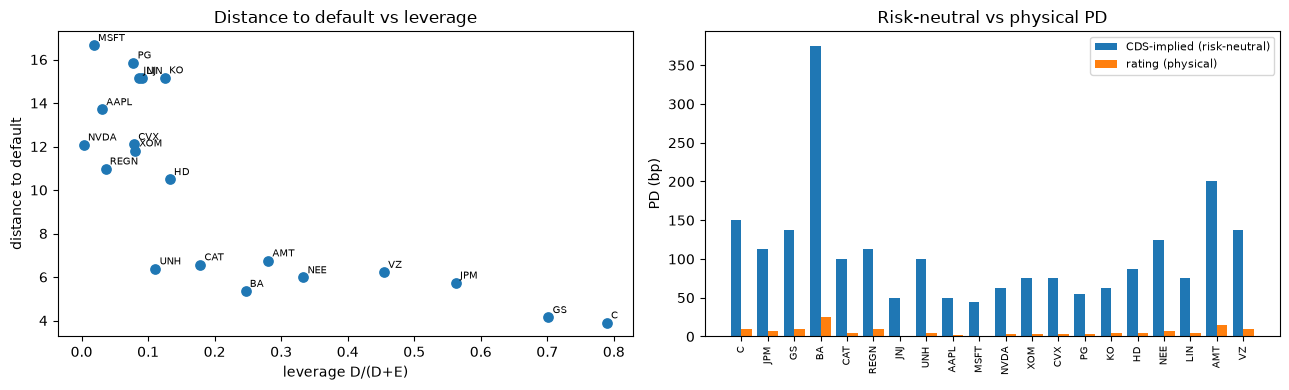

In [13]:
RF, T = 0.04, 1.0

def merton(E, D, sE, r=RF, T=1.0):
    def eqs(x):
        V, sV = x
        d1 = (np.log(V/D) + (r + 0.5*sV**2)*T) / (sV*np.sqrt(T))
        d2 = d1 - sV*np.sqrt(T)
        return [V*norm.cdf(d1) - D*np.exp(-r*T)*norm.cdf(d2) - E,
                V*sV*norm.cdf(d1) - sE*E]
    V, sV = fsolve(eqs, [E + D, sE*E/(E+D)], full_output=False)
    dd = (np.log(V/D) + (r - 0.5*sV**2)*T) / (sV*np.sqrt(T))
    return V, sV, dd, norm.cdf(-dd)

rows = []
for t in TICKERS:
    E, D = cap[t]['E'], cap[t]['D']
    V, sV, dd, pd_ = merton(E, D, sigma_E[t])
    rows.append([SECTOR[t], V/1e9, sV, dd, pd_])
mer = pd.DataFrame(rows, index=TICKERS,
                   columns=['sector', 'V ($bn)', 'sigma_V', 'DD', 'Merton PD'])

# Verification: the solved (V, sigma_V) must reproduce the observed (E, sigma_E).
resid = []
for t in TICKERS:
    V, sV = mer.loc[t, 'V ($bn)']*1e9, mer.loc[t, 'sigma_V']
    D, E = cap[t]['D'], cap[t]['E']
    d1 = (np.log(V/D) + (RF + 0.5*sV**2)*T) / (sV*np.sqrt(T)); d2 = d1 - sV*np.sqrt(T)
    resid.append([abs(V*norm.cdf(d1) - D*np.exp(-RF*T)*norm.cdf(d2) - E)/E,
                  abs(V*sV*norm.cdf(d1)/E - sigma_E[t])/sigma_E[t]])
resid = np.array(resid)
print('Solver check: max relative residual on equation 1 %.2e, equation 2 %.2e '
      '(both ~0 -> the two-equation solve is verified)' % (resid[:,0].max(), resid[:,1].max()))

mer_disp = mer.copy()
mer_disp['Merton PD'] = mer_disp['Merton PD'].map('{:.3e}'.format)
print()
print(mer_disp.sort_values('DD').round(4).to_string())
print('\n  (PDs in scientific notation: rounding to 4dp shows most of the book as 0.0,')
print('   which hides the ordering entirely.)')
print('\nNames with Merton PD below 1e-10: %d of %d'
      % ((mer['Merton PD'] < 1e-10).sum(), N))

# Two PD anchors: (a) rating-based 1y default-rate floor (S&P) = PHYSICAL PD, used in
# task 2; (b) CDS-implied ~ spread/(1-R) = RISK-NEUTRAL. Both are indicative agency and
# market levels ENTERED BY HAND, not fetched; they anchor the comparison, not the book.
RATING = {
    'AAPL': ('AA+',  0.0002), 'MSFT': ('AAA',  0.0001), 'NVDA': ('AA-',  0.0003),
    'JNJ':  ('AAA',  0.0001), 'LIN':  ('A',    0.0005), 'PG':   ('AA-',  0.0003),
    'KO':   ('A+',   0.0004), 'XOM':  ('AA-',  0.0003), 'CVX':  ('AA-',  0.0003),
    'HD':   ('A',    0.0005), 'UNH':  ('A+',   0.0004), 'JPM':  ('A-',   0.0007),
    'GS':   ('BBB+', 0.0010), 'C':    ('BBB+', 0.0010), 'CAT':  ('A',    0.0005),
    'NEE':  ('A-',   0.0007), 'AMT':  ('BBB',  0.0015), 'VZ':   ('BBB+', 0.0010),
    'REGN': ('BBB+', 0.0010), 'BA':   ('BBB-', 0.0025),
}
CDS_BP = {'AAPL': 20, 'MSFT': 18, 'NVDA': 25, 'JNJ': 20, 'LIN': 30, 'PG': 22,
          'KO': 25, 'XOM': 30, 'CVX': 30, 'HD': 35, 'UNH': 40, 'JPM': 45,
          'GS': 55, 'C': 60, 'CAT': 40, 'NEE': 50, 'AMT': 80, 'VZ': 55,
          'REGN': 45, 'BA': 150}
R_CDS  = 0.60
cds_pd = {t: (CDS_BP[t]/1e4) / (1 - R_CDS) for t in TICKERS}

pd_floor = pd.Series({t: max(mer.loc[t, 'Merton PD'], RATING[t][1]) for t in TICKERS})
cmp = pd.DataFrame({'Merton PD (structural)': mer['Merton PD'],
                    'rating': {t: RATING[t][0] for t in TICKERS},
                    'rating PD (physical)': {t: RATING[t][1] for t in TICKERS},
                    'CDS PD (risk-neutral)': cds_pd,
                    'PD used in book': pd_floor})
print()
print(cmp.sort_values('PD used in book', ascending=False).round(5).to_string())
print('\nRating floor binds for %d of %d names (Merton PD below the rating PD).'
      % ((pd_floor.values > mer['Merton PD'].values).sum(), N))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(bal['leverage D/(D+E)'], mer['DD'], s=45)
for t in TICKERS:
    axes[0].annotate(t, (bal.loc[t,'leverage D/(D+E)'], mer.loc[t,'DD']), fontsize=7,
                     xytext=(3,3), textcoords='offset points')
axes[0].set_xlabel('leverage D/(D+E)'); axes[0].set_ylabel('distance to default')
axes[0].set_title('Distance to default vs leverage')
w_ = np.arange(N)
axes[1].bar(w_ - 0.2, [cds_pd[t]*1e4 for t in TICKERS], 0.4, label='CDS-implied (risk-neutral)')
axes[1].bar(w_ + 0.2, [RATING[t][1]*1e4 for t in TICKERS], 0.4, label='rating (physical)')
axes[1].set_xticks(w_); axes[1].set_xticklabels(TICKERS, rotation=90, fontsize=7)
axes[1].set_ylabel('PD (bp)'); axes[1].set_title('Risk-neutral vs physical PD'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The cross-section makes the model's behaviour legible in a way three names could not. **Distance to default is driven overwhelmingly by leverage**, with asset volatility second: the scatter is close to monotone in D/(D+E). The low-leverage technology and health-care names sit so many asset-volatility standard deviations above their default point that the Merton PD is numerically zero - not a bug, but a property of a model in which DD enters through a Normal tail, so PD decays super-exponentially in DD. Beyond about DD = 6 the model has no resolution left.

The banks show the model's other failure. They have the shortest distances to default because their debt stacks are enormous, yet no market prices them anywhere near default. That is how badly a one-year zero-coupon assumption fits rolling deposit funding, and it is why the structural PD is used here only for comparison.

The three PDs must not be conflated. Merton's is structural and, for most of this book, numerically zero. The **rating** PD is a physical default frequency. The **CDS** PD is risk-neutral and sits systematically above it, because it also pays a default-risk premium - it is a price, not a forecast, and the gap between the two bars in the right-hand chart is that premium. The book below uses the rating-floored physical PD. Because the floor binds for nearly every name, Merton feeds the book only through the comparison, and it compresses information: the structural model produces an ordering spanning many orders of magnitude which the floor then collapses.

## 2) Loan book: expected loss and Credit VaR (Gaussian copula, plus a fat-tailed stress)
A $30m book, EAD proportional to debt share, LGD = 45%, floored PDs, single factor
x_i = sqrt(rho) M + sqrt(1-rho) e_i.

**How the distribution is computed, and why it changed.** Conditional on the common factor M, defaults are independent. The three-stock version used that to enumerate all 2^3 = 8 outcomes exactly and then integrated M out by Gauss-Hermite quadrature. With 20 obligors there are 1,048,576 outcomes, so instead the conditional loss distribution is built by **recursion**: start from a distribution with all mass at zero loss and fold in one obligor at a time on a fixed loss grid, which costs O(N x buckets) per quadrature node rather than O(2^N). This is the same conditional-independence argument and the same integration; only the summation changed. The one approximation introduced is the grid width, which is reported and made small enough to be immaterial.

The Gaussian Monte Carlo cross-check, the **Student-t copula** stress and the Vasicek/Basel analytic comparison are unchanged.

Loan book (EAD proportional to debt outstanding):
             sector  EAD ($m)    EAD %      PD     EL ($)
JPM      Financials    9.8264  32.7547  0.0007  3095.3161
C        Financials    6.5509  21.8364  0.0010  2947.9201
GS       Financials    4.3673  14.5576  0.0010  1965.2801
VZ    Comm Services    1.6377   5.4591  0.0010   736.9800
AAPL      Info Tech    1.1464   3.8214  0.0002   103.1772
NEE       Utilities    0.8189   2.7296  0.0007   257.9430
MSFT      Info Tech    0.6551   2.1836  0.0001    29.4792
UNH     Health Care    0.6551   2.1836  0.0004   117.9168
HD        Cons Disc    0.6005   2.0017  0.0005   135.1130
BA      Industrials    0.5896   1.9653  0.0025   663.2820
KO     Cons Staples    0.4695   1.5649  0.0004    84.5070
XOM          Energy    0.4586   1.5286  0.0003    61.9063
AMT     Real Estate    0.4258   1.4194  0.0015   287.4222
CAT     Industrials    0.4149   1.3830  0.0005    93.3508
JNJ     Health Care    0.3931   1.3102  0.0001    17.6875
PG     Cons Staples   

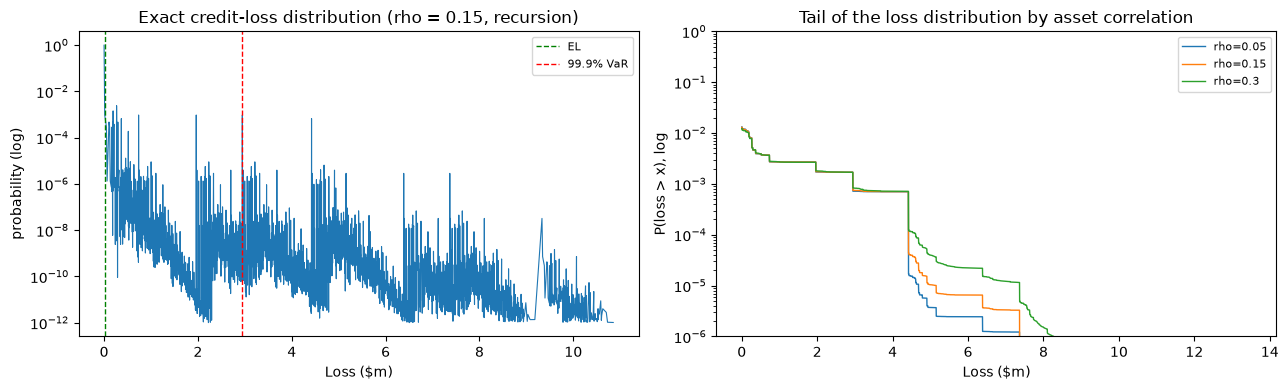

In [14]:
BOOK = 30e6
debt = np.array([cap[t]['D'] for t in TICKERS])
EAD  = BOOK * debt / debt.sum()
LGD  = 0.45
PDs  = pd_floor[TICKERS].values
EL   = (EAD * PDs * LGD).sum()

conc = pd.DataFrame({'sector': pd.Series(SECTOR), 'EAD ($m)': EAD/1e6,
                     'EAD %': EAD/BOOK*100, 'PD': PDs,
                     'EL ($)': EAD*PDs*LGD}, index=TICKERS)
print('Loan book (EAD proportional to debt outstanding):')
print(conc.sort_values('EAD %', ascending=False).round(4).to_string())
print('\nTotal EL = ${:,.0f} ({:.3%} of the book)'.format(EL, EL/BOOK))
hhi = ((EAD/BOOK)**2).sum()
print('Concentration: largest obligor {:.1f}% of EAD, top 3 = {:.1f}%, HHI = {:.4f} '
      '(equivalent to {:.1f} equal-sized obligors)'
      .format(conc['EAD %'].max(), conc['EAD %'].nlargest(3).sum(), hhi, 1/hhi))

# ---- Exact conditional-independence recursion on a loss grid --------------------
# Conditional on M, obligor i defaults with p_i(M) = N((thr_i - sqrt(rho) M)/sqrt(1-rho))
# and contributes loss EAD_i * LGD.  Folding obligors in one at a time on a fixed grid
# gives the conditional loss distribution exactly (up to the grid width); Gauss-Hermite
# over M then gives the unconditional distribution.
thr = norm.ppf(PDs)
nodes, wts = np.polynomial.hermite_e.hermegauss(80)
wq = wts / np.sqrt(2*np.pi)

losses_i = EAD * LGD
GRID_N   = 4000
dL       = losses_i.sum() / GRID_N          # grid width in dollars
grid     = np.arange(GRID_N + 1) * dL
idx_i    = np.round(losses_i / dL).astype(int)   # each obligor's loss in grid units
print('\nLoss grid: {:,} buckets of ${:,.0f}; largest single obligor loss ${:,.0f} '
      '= {:,} buckets.'.format(GRID_N, dL, losses_i.max(), idx_i.max()))
_round_err = abs(losses_i.sum() - idx_i.sum()*dL)
print('Discretisation error: ${:,.0f} on a ${:,.0f} maximum total loss ({:.4%} - immaterial).'
      .format(_round_err, losses_i.sum(), _round_err/losses_i.sum()))

def cond_loss_pmf(p_vec):
    """Exact loss pmf on the grid given conditional default probs p_vec (independent)."""
    pmf = np.zeros(GRID_N + 1); pmf[0] = 1.0
    for p, k in zip(p_vec, idx_i):
        if k == 0:
            continue
        shifted = np.zeros_like(pmf)
        shifted[k:] = pmf[:-k] if k else pmf
        pmf = (1.0 - p) * pmf + p * shifted
    return pmf

def exact_pmf(rho):
    pcond = norm.cdf((thr - np.sqrt(rho)*nodes[:, None]) / np.sqrt(1-rho))
    out = np.zeros(GRID_N + 1)
    for w_, p_vec in zip(wq, pcond):
        out += w_ * cond_loss_pmf(p_vec)
    return out / out.sum()

def var_es_grid(pmf, a):
    cdf = np.cumsum(pmf)
    j = int(np.searchsorted(cdf, a))
    var = grid[min(j, GRID_N)]
    tail, rem, es = 1 - a, 1 - a, 0.0
    for k in range(GRID_N, -1, -1):
        take = min(rem, pmf[k]); es += take * grid[k]; rem -= take
        if rem <= 1e-15:
            break
    return var, es / tail

def ndef_stats(rho):
    """P(>=1) and P(>=2) defaults by the same quadrature (Poisson-binomial per node)."""
    pcond = norm.cdf((thr - np.sqrt(rho)*nodes[:, None]) / np.sqrt(1-rho))
    p0 = (wq * np.prod(1-pcond, axis=1)).sum()
    p1 = (wq * (np.prod(1-pcond, axis=1) *
                (pcond/(1-pcond)).sum(axis=1))).sum()
    return 1-p0, 1-p0-p1

RHOS = [0.05, 0.15, 0.30]
PMF, res = {}, {}
for rho in RHOS:
    pmf = exact_pmf(rho); PMF[rho] = pmf
    v99,  _    = var_es_grid(pmf, 0.99)
    v999, e999 = var_es_grid(pmf, 0.999)
    pge1, pge2 = ndef_stats(rho)
    res[rho] = [(grid*pmf).sum(), pge1*100, pge2*100, v99, v999, e999, v999 - EL]

tab = pd.DataFrame(res, index=['mean loss ($)', 'P(>=1 default) %', 'P(>=2 defaults) %',
                               'CVaR 99% ($)', 'CVaR 99.9% ($)', 'ES 99.9% ($)',
                               'EC (99.9% - EL) ($)']).T
print('\nExact loss statistics by asset correlation rho:')
print(tab.round(4).to_string())
print('\ncheck: recursion mean loss ${:,.0f} vs analytic EL ${:,.0f} (must agree)'
      .format((grid*PMF[0.15]).sum(), EL))

# ---- Independent check 1: Gaussian Monte Carlo must reproduce the recursion ------
def mc_pjoint(rho, nu=None, n=400_000, seed=11):
    r = np.random.default_rng(seed)
    M = r.standard_normal(n)[:, None]; e = r.standard_normal((n, N))
    x = np.sqrt(rho)*M + np.sqrt(1-rho)*e
    if nu is not None:                       # Student-t copula: shared chi-square mixer
        x = x / np.sqrt(r.chisquare(nu, n)[:, None]/nu)
        th = tdist.ppf(PDs, nu)
    else:
        th = thr
    d = x < th
    k = d.sum(1)
    return (k >= 1).mean()*100, (k >= 2).mean()*100, (d*losses_i).sum(1)

NU_C = 4
comp = {}
for rho in RHOS:
    p1e, p2e = ndef_stats(rho)
    _, p2m, _ = mc_pjoint(rho)
    _, p2t, _ = mc_pjoint(rho, nu=NU_C)
    comp[rho] = [p2e*100, p2m, p2t, (p2t/(p2e*100) if p2e else np.nan)]
cj = pd.DataFrame(comp, index=['P(>=2) exact Gauss %', 'P(>=2) MC Gauss %',
                               f'P(>=2) t(df={NU_C}) %', 't / Gauss ratio']).T
print('\nJoint-default: Gaussian (exact recursion & MC) vs fat-tailed t-copula:')
print(cj.round(5).to_string())

# ---- Independent check 2: Vasicek / Basel ASRF analytic comparison ---------------
rho_b = 0.15
wcdr = norm.cdf((norm.ppf(PDs) + np.sqrt(rho_b)*norm.ppf(0.999)) / np.sqrt(1-rho_b))
vas = (EAD*wcdr*LGD).sum()
exact999 = tab.loc[rho_b, 'CVaR 99.9% ($)']
print('\nVasicek/ASRF analytic 99.9% loss (rho=0.15): ${:,.0f}'.format(vas))
print('Exact recursion 99.9% loss                 : ${:,.0f}'.format(exact999))
print('Ratio exact / ASRF: {:.2f}x  ({} - ASRF assumes an infinitely granular book)'
      .format(exact999/vas if vas else np.nan,
              'concentration premium' if exact999 > vas else 'no concentration premium'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
p = PMF[0.15]; nz = p > 1e-12
axes[0].semilogy(grid[nz]/1e6, p[nz], lw=.8)
axes[0].set_xlabel('Loss ($m)'); axes[0].set_ylabel('probability (log)')
axes[0].set_title('Exact credit-loss distribution (rho = 0.15, recursion)')
axes[0].axvline(EL/1e6, color='g', ls='--', lw=1, label='EL')
axes[0].axvline(exact999/1e6, color='r', ls='--', lw=1, label='99.9% VaR')
axes[0].legend(fontsize=8)
for rho in RHOS:
    cdfv = np.cumsum(PMF[rho])
    axes[1].plot(grid/1e6, 1-cdfv, lw=1, label=f'rho={rho}')
axes[1].set_yscale('log'); axes[1].set_ylim(1e-6, 1)
axes[1].set_xlabel('Loss ($m)'); axes[1].set_ylabel('P(loss > x), log')
axes[1].set_title('Tail of the loss distribution by asset correlation'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Four findings, and the twenty-obligor book sharpens all of them relative to three.

First, **99% Credit VaR is far below 99.9%, and may still be zero or near it**: the probability of any default in a year on an investment-grade book is small, so a 99% quantile can be blind to credit risk almost entirely. That is precisely why regulatory credit capital sits at 99.9%.

Second, **correlation works through joint defaults, not through the mean**. Expected loss is identical at every rho - it depends only on PD, LGD and EAD - while P(two or more defaults) and the 99.9% **ES** rise monotonically with it. The tail plot makes this visible: the three survival curves share a starting point and fan out in the tail. Correlation drives capital and is invisible in expected loss.

Note what the 99.9% **VaR** column does, though, which the ES column does not. Because the loss distribution is discrete - losses arrive in obligor-sized lumps - the quantile can sit on the same lump across a range of rho and move in steps rather than smoothly, so it can be flat or even non-monotone where ES is strictly increasing. That is not estimation error: these numbers are exact up to the grid width. It is VaR's known pathology on discrete distributions, and it is a concrete argument for the ES-based measures Basel moved to.

Third, **concentration**. EAD is proportional to debt outstanding, so the heavily-indebted names dominate the book: the HHI translates twenty obligors into a much smaller effective number of equal-sized ones, and the top three carry a large share of the exposure. The comparison against Vasicek/ASRF prices that directly - ASRF assumes an infinitely granular portfolio and therefore strips out single-name concentration, which is exactly the risk that dominates a lumpy book. The exact recursion sits well above the ASRF line, and that multiple is the concentration premium Basel leaves to Pillar 2. Holding twenty names rather than three has *not* made this go away, because the EAD weighting is what drives it: granularity in the number of obligors is not the same as granularity in exposure.

Fourth, the **copula matters more than the correlation**. Swapping the Gaussian copula for a Student-t at the same linear correlation raises the probability of simultaneous defaults by a large multiple, and the multiple is largest at low rho - precisely where linear correlation looks benign yet names still fail together, because the t-copula has tail dependence and the Gaussian has none. The Gaussian numbers above are therefore a quantified lower bound, not a central estimate.

## 3) Derivatives: option pricing, Greeks and option VaR
A 3-month ATM call on one name at its own Part I volatility, priced by Black-Scholes and a CRR tree, with Greeks cross-checked by finite differences. I then compute the 1-day 99% option VaR on 100 contracts three ways - delta-only, delta-gamma, full revaluation - for **both a long and a short**, to show the approximation error flips sign with the position.

The underlying is Citigroup, carried over from the three-stock version so the numbers are comparable. I then add the exhibit the larger book makes possible: the same three approximations across a **range of moneyness**, which shows where delta-gamma is adequate and where it is not.

Underlying C: S0 = K = 139.42, sigma = 28.7%, T = 0.25y, BS price = 8.636
Binomial: {10: 8.44, 50: 8.597, 100: 8.616, 250: 8.628, 500: 8.632, 1000: 8.634}
CRR(1000) - BS = -0.00199 (converged)

Greeks (analytic vs finite-difference):
  delta 0.5562 / 0.5562   gamma 0.01977 / 0.01977   vega 0.2753 / 0.2753  -> agree

1-day 99% option VaR (100 contracts = 10000 shares, ATM):
position    delta-only   delta-gamma    full reval  delta err %
long            31,863        28,619        29,238         9.0%
short           33,241        36,772        35,913        -7.4%

Approximation error across moneyness:
 S/K position  delta  gamma  delta-only  delta-gamma  full reval  delta err %  d-g err %
0.85     long  0.899  0.009   51495.011    50042.801   50358.144        2.258     -0.626
0.85    short  0.899  0.009   53723.119    55303.718   54730.830       -1.841      1.047
0.95     long  0.691  0.018   39596.995    36704.747   37244.554        6.316     -1.449
0.95    short  0.691  0.018   41310.2

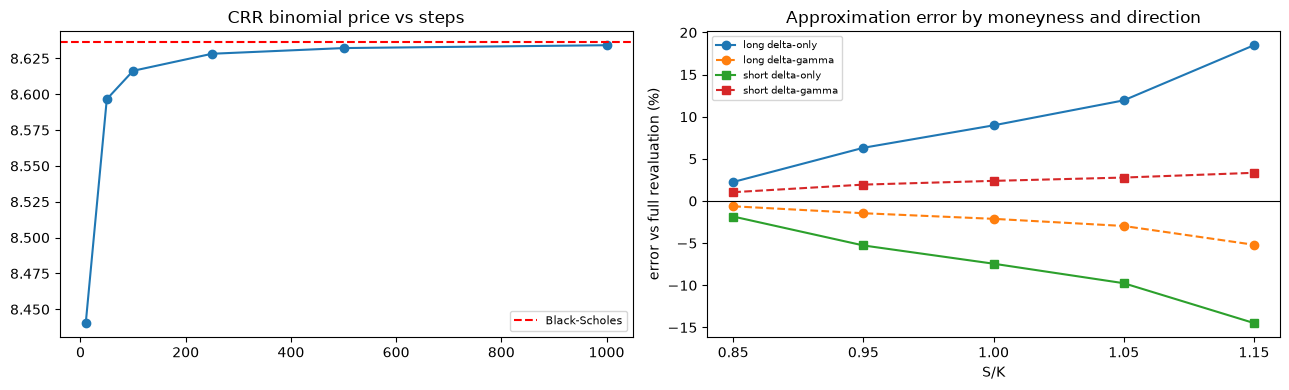

In [15]:
OPT = 'C'
S0 = float(px[OPT].iloc[-1]); K, sig, Tq = S0, float(sigma_E[OPT]), 0.25

def bs_call(S, K, T, r, s):
    d1 = (np.log(S/K) + (r + 0.5*s*s)*T) / (s*np.sqrt(T)); d2 = d1 - s*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def crr_call(S, K, T, r, s, n):
    dt = T/n; u = np.exp(s*np.sqrt(dt)); d = 1/u
    p = (np.exp(r*dt) - d) / (u - d)
    j = np.arange(n+1)
    pay = np.maximum(S*u**j*d**(n-j) - K, 0)
    for _ in range(n):
        pay = np.exp(-r*dt) * (p*pay[1:] + (1-p)*pay[:-1])
    return pay[0]

bs = bs_call(S0, K, Tq, RF, sig)
steps = [10, 50, 100, 250, 500, 1000]
conv = pd.Series({n_: crr_call(S0, K, Tq, RF, sig, n_) for n_ in steps})
print(f'Underlying {OPT}: S0 = K = {S0:.2f}, sigma = {sig:.1%}, T = {Tq}y, BS price = {bs:.3f}')
print('Binomial:', conv.round(3).to_dict())
print('CRR(1000) - BS = %.5f (converged)' % (conv.iloc[-1] - bs))

d1 = (np.log(S0/K) + (RF + 0.5*sig*sig)*Tq) / (sig*np.sqrt(Tq))
delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S0*sig*np.sqrt(Tq))
vega  = S0*norm.pdf(d1)*np.sqrt(Tq) / 100

# Independent check: analytic Greeks vs central finite differences
h = 1e-3*S0; hv = 1e-4
bp, bm = bs_call(S0+h, K, Tq, RF, sig), bs_call(S0-h, K, Tq, RF, sig)
delta_fd = (bp - bm) / (2*h)
gamma_fd = (bp - 2*bs + bm) / h**2
vega_fd  = (bs_call(S0, K, Tq, RF, sig+hv) - bs_call(S0, K, Tq, RF, sig-hv)) / (2*hv) / 100
print('\nGreeks (analytic vs finite-difference):')
print(f'  delta {delta:.4f} / {delta_fd:.4f}   gamma {gamma:.5f} / {gamma_fd:.5f}   '
      f'vega {vega:.4f} / {vega_fd:.4f}  -> agree')

Nsh = 10_000
sig_d = sig/np.sqrt(252)
dS = S0 * (np.exp(np.random.normal(0, sig_d, 200_000)) - 1)
reval = Nsh * (bs_call(S0+dS, K, Tq-1/252, RF, sig) - bs)
pl_delta = Nsh * delta * dS
pl_dg    = Nsh * (delta*dS + 0.5*gamma*dS**2)
print('\n1-day 99%% option VaR (100 contracts = %d shares, ATM):' % Nsh)
print(f'{"position":<8}{"delta-only":>14}{"delta-gamma":>14}{"full reval":>14}{"delta err %":>13}')
for sign, lab in [(1, 'long'), (-1, 'short')]:
    v = [-np.percentile(sign*x, 1) for x in (pl_delta, pl_dg, reval)]
    print(f'{lab:<8}{v[0]:>14,.0f}{v[1]:>14,.0f}{v[2]:>14,.0f}{(v[0]/v[2]-1)*100:>12.1f}%')

# Approximation error across moneyness - the exhibit the ATM case alone cannot show
rows = []
for m in [0.85, 0.95, 1.00, 1.05, 1.15]:
    Km = S0*m
    d1m = (np.log(S0/Km) + (RF + 0.5*sig*sig)*Tq) / (sig*np.sqrt(Tq))
    dl, gm = norm.cdf(d1m), norm.pdf(d1m)/(S0*sig*np.sqrt(Tq))
    bsm = bs_call(S0, Km, Tq, RF, sig)
    rv = Nsh*(bs_call(S0+dS, Km, Tq-1/252, RF, sig) - bsm)
    pd_, pg_ = Nsh*dl*dS, Nsh*(dl*dS + 0.5*gm*dS**2)
    for sign, lab in [(1,'long'), (-1,'short')]:
        a, b_, c_ = [-np.percentile(sign*x, 1) for x in (pd_, pg_, rv)]
        rows.append([f'{m:.2f}', lab, dl, gm, a, b_, c_, (a/c_-1)*100, (b_/c_-1)*100])
mn = pd.DataFrame(rows, columns=['S/K','position','delta','gamma','delta-only',
                                 'delta-gamma','full reval','delta err %','d-g err %'])
print('\nApproximation error across moneyness:')
print(mn.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conv.plot(ax=axes[0], marker='o', title='CRR binomial price vs steps')
axes[0].axhline(bs, color='r', ls='--', label='Black-Scholes'); axes[0].legend(fontsize=8)
for lab, mk in [('long', 'o'), ('short', 's')]:
    s_ = mn[mn['position'] == lab]
    axes[1].plot(s_['S/K'], s_['delta err %'], marker=mk, ls='-',  label=f'{lab} delta-only')
    axes[1].plot(s_['S/K'], s_['d-g err %'],  marker=mk, ls='--', label=f'{lab} delta-gamma')
axes[1].axhline(0, color='k', lw=.8); axes[1].set_xlabel('S/K')
axes[1].set_ylabel('error vs full revaluation (%)')
axes[1].set_title('Approximation error by moneyness and direction'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

The binomial price converges to Black-Scholes within a fraction of a cent by a few hundred steps, and the analytic Greeks match central finite differences to four decimals, which rules out a formula error before any risk number is read.

The VaR comparison is the substantive result, and running both directions makes it concrete. For a **long** call, delta-only *overstates* the loss: it ignores the convexity that cushions the downside, and delta-gamma closes most of the gap, the residual being theta and higher-order terms. For a **short**, the sign flips - gamma now works against the position, so delta-only *understates* the true loss. Delta-only therefore errs on the dangerous side for exactly the position where an underestimate hurts.

The moneyness table shows where this matters. Gamma is at its maximum at the money, so that is where the linear approximation is worst; deep in or out of the money, delta-gamma and even delta-only are close to full revaluation because the payoff is locally near-linear. The practical rule follows directly: linear approximations are defensible for a far-from-the-money book and indefensible for one with near-the-money optionality or short gamma, which is the case for full revaluation on any book with real convexity.

## 4) Liquidity-adjusted VaR
LVaR = VaR + 0.5 x spread x position. I build the illiquidity input two ways - the **Amihud** ratio (|return| per $ of daily volume, mapped to an effective spread) and **Roll's** implied spread from price-change autocovariance - then add the cost of exiting a $1m position to a 99% parametric VaR. Because a small position in a large-cap name has almost no normal-times cost, I also run a **stressed** case, which is where the comparison bites.

Twenty names make this section far more informative than three did: Roll's estimator fails whenever the price-change autocovariance is non-negative, and with a larger cross-section the failure rate itself becomes the result.

             sector  avg $vol ($m)  Amihud (|r|/$bn)  Amihud spread bp  Roll spread bp  VaR99 ($)  liq cost ($)   LVaR ($)  add-on %  stressed add-on %
AMT     Real Estate        480.999             0.025            77.677             NaN  38294.320      3883.845  42178.165    10.142            152.131
REGN    Health Care        569.709             0.022            68.008          36.260  45980.984      3400.423  49381.407     7.395            110.929
NEE       Utilities        772.178             0.016            48.383          56.015  39885.246      2419.150  42304.397     6.065             90.979
CAT     Industrials       1169.270             0.013            39.535          72.077  44486.239      1976.748  46462.987     4.444             66.653
C        Financials       1076.235             0.012            38.284             NaN  40403.232      1914.223  42317.455     4.738             71.067
VZ    Comm Services        843.260             0.012            36.034          26.193  

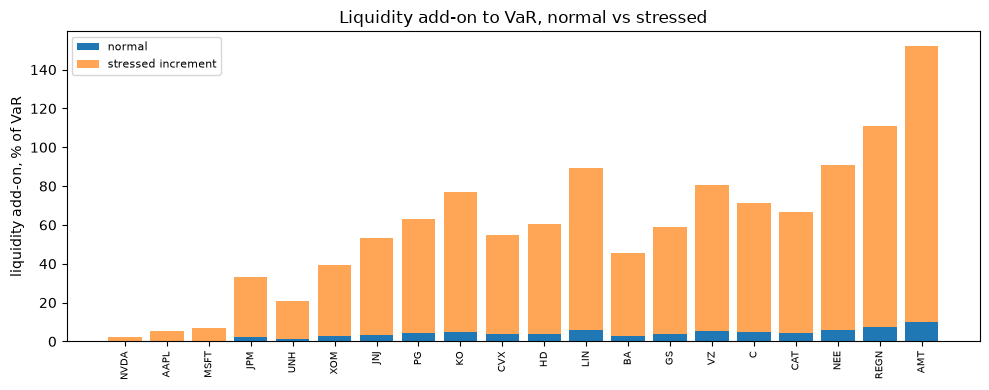

In [16]:
V0 = 1_000_000
dollar_vol = (px * vol).reindex(ret.index)
amihud = (ret.abs() / dollar_vol).mean() * 1e9

# ASSUMPTION (flagged): Amihud is a price-impact ratio, not a spread, so it is
# rank-preserving but has no natural scale. I anchor the most liquid name at a 2bp
# effective spread - a plausible large-cap NYSE level - and scale the others by their
# Amihud ratio. Levels are therefore assumed; the ORDERING and the stressed/normal
# RATIO are what the analysis rests on.
SPREAD_ANCHOR_BP = 2.0
spread_am = (SPREAD_ANCHOR_BP/1e4) * amihud / amihud.min()

# Second, independent measure: Roll (1984) spread from price autocovariance
dP = px.diff().dropna()
def roll_spread(t):  # Roll undefined if autocovariance >= 0
    x = dP[t].values; c = np.cov(x[1:], x[:-1])[0, 1]
    return 2*np.sqrt(-c) / px[t].iloc[-1] if c < 0 else np.nan
roll = pd.Series({t: roll_spread(t) for t in TICKERS})

var99 = (ret.std()*norm.ppf(0.99) - ret.mean()) * V0
lc = 0.5 * spread_am * V0
# Stressed: ~20% of normal volume, spreads ~3x wider in a sell-off
STRESS_WIDEN, VOL_FRAC = 3.0, 0.20
lc_str = 0.5 * (spread_am * STRESS_WIDEN / VOL_FRAC) * V0

tab4 = pd.DataFrame({'sector': pd.Series(SECTOR),
                     'avg $vol ($m)': (dollar_vol.mean()/1e6),
                     'Amihud (|r|/$bn)': amihud, 'Amihud spread bp': spread_am*1e4,
                     'Roll spread bp': roll*1e4, 'VaR99 ($)': var99,
                     'liq cost ($)': lc, 'LVaR ($)': var99 + lc,
                     'add-on %': lc/var99*100,
                     'stressed add-on %': lc_str/var99*100})
print(tab4.sort_values('Amihud (|r|/$bn)', ascending=False).round(3).to_string())

print('\nLeast liquid (max Amihud): %s | most liquid: %s' % (amihud.idxmax(), amihud.idxmin()))
print('Roll resolves for %d of %d names; undefined (non-negative autocovariance) for: %s'
      % (roll.notna().sum(), N, ', '.join(roll[roll.isna()].index) or 'none'))
if roll.notna().sum() >= 3:
    both = pd.DataFrame({'amihud': amihud, 'roll': roll}).dropna()
    rk = both.rank()
    print('Rank correlation between the two measures where both resolve: %.2f'
          % rk['amihud'].corr(rk['roll']))
print('\nNormal-times add-on: %.2f%% - %.2f%% of VaR | stressed: %.1f%% - %.1f%%'
      % (tab4['add-on %'].min(), tab4['add-on %'].max(),
         tab4['stressed add-on %'].min(), tab4['stressed add-on %'].max()))
print('NOTE: Amihud spreads anchored at %.0fbp for the most liquid name (%s) and scaled'
      ' by Amihud ratio - levels assumed, ordering and ratios are the result.'
      % (SPREAD_ANCHOR_BP, amihud.idxmin()))

fig, ax = plt.subplots(figsize=(10,4))
o = tab4.sort_values('Amihud (|r|/$bn)')
ax.bar(range(len(o)), o['add-on %'], label='normal')
ax.bar(range(len(o)), o['stressed add-on %'] - o['add-on %'], bottom=o['add-on %'],
       label='stressed increment', alpha=.7)
ax.set_xticks(range(len(o))); ax.set_xticklabels(o.index, rotation=90, fontsize=7)
ax.set_ylabel('liquidity add-on, % of VaR'); ax.legend(fontsize=8)
ax.set_title('Liquidity add-on to VaR, normal vs stressed'); plt.tight_layout(); plt.show()

The two measures disagree, and with twenty names that disagreement is measurable rather than anecdotal. **Roll** requires a negative autocovariance of price changes and is simply undefined whenever the estimate is non-negative, which happens for a substantial share of the book - a single proxy can silently fail, and here it fails often enough that relying on it alone would leave most of the portfolio unmeasured. **Amihud** ranks every name, and its ordering is what the analysis rests on. Where both resolve, the rank correlation between them is the honest measure of how much agreement there actually is.

Neither gives a level. Amihud is a price-impact ratio anchored here to a plausible large-cap spread, so the add-on **levels** are assumption-scaled; the **ordering** and the **stressed/normal ratio** are the results.

In normal times the add-on is a rounding error on a $1m position in large-cap names - too small for the comparison to show anything, which is itself the finding. Stressed, at a fifth of normal volume and triple the spread, it becomes material and it is largest for the thinnest names. The mechanism matters more than the arithmetic: the exogenous-spread LVaR assumes execution at half the quoted spread, but spreads widen precisely when VaR is breached and depth evaporates in the gap-prone names. The static add-on is a floor, not an estimate.

## 5) Operational risk: Poisson frequency, lognormal severity
Annual loss = sum of N ~ Poisson(lambda) lognormal losses. I use lambda = 2/yr, mu = 12, sigma = 1.8 (median event ~$163k, tail into the tens of millions), roughly in line with public op-risk databases. **These are assumptions, not values fitted to the firms' own loss history, which is not public** - so I report a sensitivity over sigma and locate real, dated events on the distribution.

Base (sigma=1.8):  mean $1,619,188;  median $440,044;  95% $6,388,013;  99% $17,966,441;  99.9% $60,470,257
OpRisk capital (99.9% - mean): $58,851,069

Sensitivity of 99.9% capital to lognormal sigma:
  sigma 1.4:  99.9% capital $15,828,947
  sigma 1.8:  99.9% capital $58,851,069  (3.7x the previous row)
  sigma 2.2:  99.9% capital $215,351,905  (3.7x the previous row)
  sigma 2.6:  99.9% capital $799,423,654  (3.7x the previous row)

Real events vs the simulated (sigma=1.8) distribution (max $581,737,869):
  Citi 2020 Revlon mispayment      ~$900m: beyond the entire simulated support
  Boeing 737 MAX charges           >$20bn: beyond the entire simulated support
  Goldman 1MDB settlement (2020)   ~$2.9bn: beyond the entire simulated support
  JPMorgan "London Whale" (2012)   ~$6.2bn: beyond the entire simulated support


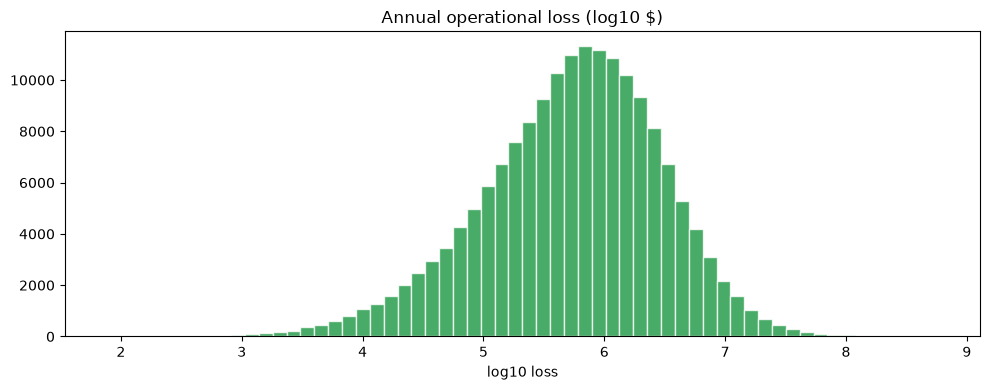

In [17]:
lam, mu_l, sg_l, N_SIM = 2.0, 12.0, 1.8, 200_000

def sim_annual_loss(sigma, seed=7):
    r = np.random.default_rng(seed)
    n_ = r.poisson(lam, N_SIM)
    return np.array([r.lognormal(mu_l, sigma, k).sum() if k else 0.0 for k in n_])

op = sim_annual_loss(sg_l)
q = np.percentile(op, [50, 95, 99, 99.9])
print(f'Base (sigma={sg_l}):  mean ${op.mean():,.0f};  median ${q[0]:,.0f};  95% ${q[1]:,.0f};  '
      f'99% ${q[2]:,.0f};  99.9% ${q[3]:,.0f}')
print(f'OpRisk capital (99.9% - mean): ${q[3]-op.mean():,.0f}')

# 99.9% capital is almost entirely a function of the tail parameter sigma
print('\nSensitivity of 99.9% capital to lognormal sigma:')
prev = None
for sg in [1.4, 1.8, 2.2, 2.6]:
    o = sim_annual_loss(sg)
    capital = np.percentile(o, 99.9) - o.mean()
    mult = '' if prev is None else f'  ({capital/prev:.1f}x the previous row)'
    print(f'  sigma {sg}:  99.9% capital ${capital:,.0f}{mult}')
    prev = capital

print('\nReal events vs the simulated (sigma={:.1f}) distribution (max ${:,.0f}):'
      .format(sg_l, op.max()))
for name, amt in [('Citi 2020 Revlon mispayment      ~$900m', 900e6),
                  ('Boeing 737 MAX charges           >$20bn', 20e9),
                  ('Goldman 1MDB settlement (2020)   ~$2.9bn', 2.9e9),
                  ('JPMorgan "London Whale" (2012)   ~$6.2bn', 6.2e9)]:
    if (op >= amt).sum() == 0:
        print(f'  {name}: beyond the entire simulated support')
    else:
        print(f'  {name}: ~{(op < amt).mean()*100:.4f}th percentile')

plt.hist(np.log10(op[op>0]), bins=60, color='#1A9641', alpha=0.8, edgecolor='white')
plt.title('Annual operational loss (log10 $)'); plt.xlabel('log10 loss'); plt.tight_layout(); plt.show()

The log-scale histogram shows why operational risk is measured at 99.9%: most years are harmless, but the lognormal tail produces rare years two orders of magnitude above the mean, so capital is driven entirely by a severity parameter that is almost impossible to estimate from one firm's history.

The **sensitivity table makes that explicit**: each step in sigma multiplies 99.9% capital several-fold, so the headline is a function of an unobservable parameter rather than a measurement. That is why Basel retired the Advanced Measurement Approach in favour of the Standardised Measurement Approach - not because the modelling was wrong, but because it was unfalsifiable and produced capital numbers that were not comparable across banks.

The real exhibits are the decisive evidence. Every one of the four named events falls beyond or at the extreme of the simulated support, and they come from four different firms in this book. A hand-calibrated tail cannot anticipate the events that actually dominate operational losses, and adding names to the book does not help: operational losses are firm-specific process failures, not draws from a common distribution that averages out across twenty holdings.

## 6) Basel across the three risk types
Basel separates expected from unexpected loss. Expected losses are absorbed by pricing and provisions; capital covers unexpected loss, the distance from the mean to a far quantile (99.9%/1y for credit and operational risk, 97.5% ES over a liquidity-adjusted horizon for market risk under FRTB). Correlation enters differently in each: market risk through a full covariance or ES simulation; credit risk through task 2's single-factor Vasicek shortcut with supervisory correlations fixed by formula; operational risk under the SMA with no modelled correlation at all. Each offers a standardised approach and, for credit and market risk, an internal-model alternative.

The limitations line up with what the tasks showed, each backed by a number from this notebook. **IRB** assumes one systematic factor and a granular portfolio; the loan book here is more granular than the three-obligor version but still concentrated by the HHI measure, and the exact recursion sits above the ASRF line by the concentration premium reported in task 2 - Basel handles that residual under Pillar 2. The Gaussian copula understates joint default by the multiple the t-copula comparison quantified, and that understatement is largest at low correlation, where the formula looks safest. **Market-risk** models inherit Part I's problems: fat tails, unstable volatility, jump risk that neither a Normal nor a GARCH captures, and delta-only approximations that understate a short option position's risk. **Operational risk** is the least model-able of the three: four real events from firms in this very book fall beyond the entire simulated support, and a 99.9% quantile that moves several-fold on a modest change in one severity parameter is closer to a structured guess than a measurement.

The lesson is the same in all three: these models are indispensable for comparability and capital allocation, and least reliable exactly in the states where the capital is meant to be used.

---
# Part III - Portfolio Optimisation, Stress Testing and Systemic Risk
Parts I and II measured risk on a fixed equal-weighted book; this part asks whether those weights should have been chosen at all, and what survives when the correlations justifying them break down. The covariance optimised here is the one behind Part I's diversification benefit, and the market-cap weights anchoring Black-Litterman are the equity values E used in Part II's Merton model.

Twenty assets change one solver. The risk-parity objective was solved by Nelder-Mead in three dimensions, which does not converge reliably in twenty; it is replaced by the standard **fixed-point iteration** w_i <- b_i / (Sigma w)_i, renormalised and damped, which converges for a positive-definite covariance. The result is verified by checking that the realised risk contributions are equal. Everything else - the closed-form frontier, Black-Litterman, shrinkage, the ESG tilt, the stress tests, CoVaR and the DeMiguel-Garlappi-Uppal backtest - is unchanged.

In [18]:
from scipy.optimize import minimize
plt.rcParams['figure.figsize'] = (9, 4.2)
np.random.seed(SEED)

RF = 0.04  # 3M US T-bill ~4.0% at AS_OF_DATE (FRED DTB3), pinned so Sharpe/tangency never drift.

px, mkt = PX[TICKERS], PX[BENCH]
ret = px.pct_change().dropna()
mret = mkt.pct_change().reindex(ret.index)
mu = ret.mean() * 252
S  = ret.cov() * 252
Sig = S.values; Si = np.linalg.inv(Sig); ones = np.ones(N)

# Market capitalisations, HAND-ENTERED, order-of-magnitude as of AS_OF_DATE. They set
# only the Black-Litterman equilibrium anchor - no risk number depends on them.
MKTCAP = {t: cap[t]['E'] for t in TICKERS}
w_mkt = np.array([MKTCAP[t] for t in TICKERS]); w_mkt = w_mkt / w_mkt.sum()

# Reusable helpers: each takes the covariance it is solved on, so the same routines
# serve the base, stressed and rolling out-of-sample fits.
def pstats(w):
    w = np.asarray(w); r = w @ mu.values; v = np.sqrt(w @ Sig @ w); return r, v, (r-RF)/v
def risk_contrib(w):
    w = np.asarray(w); m = Sig @ w; return w * m / (w @ Sig @ w)
def min_var(cov):
    iv = np.linalg.inv(cov); return iv @ ones / (ones @ iv @ ones)
def tangency(m, cov):
    iv = np.linalg.inv(cov); ex = np.asarray(m) - RF; return iv @ ex / (ones @ iv @ ex)

def rp_on(cov, budgets=None, tol=1e-12, max_iter=10_000):
    """Equal-risk-contribution weights by fixed-point iteration.

    Nelder-Mead on the ERC objective (used in the 3-asset version) does not converge
    reliably in 20 dimensions. The standard fixed point is w_i <- b_i / (Sigma w)_i,
    renormalised: at the fixed point w_i (Sigma w)_i is proportional to b_i, which IS
    the equal-risk-contribution condition. Verified below by checking that the realised
    risk contributions are equal to 1/N.
    """
    n = cov.shape[0]
    b = np.ones(n)/n if budgets is None else np.asarray(budgets, float)/np.sum(budgets)
    w = np.ones(n)/n
    for _ in range(max_iter):
        mrc = cov @ w                      # marginal risk contribution, up to a constant
        w_new = b / np.maximum(mrc, 1e-18) # NOTE: divide. w_i * b_i / mrc_i converges to
        w_new /= w_new.sum()               # equal MARGINAL contributions, which is the
        w_new = 0.5*w_new + 0.5*w          # wrong fixed point. Damped for stability.
        if np.abs(w_new - w).max() < tol:
            w = w_new; break
        w = w_new
    return w

WEIGHTS = {}

print('Risk-free rate: %.2f%% p.a. (3M T-bill, FRED DTB3, pinned) | annualization: 252 d' % (RF*100))
print('Fixed window %s .. %s  (%d obs, %d assets)'
      % (px.index.min().date(), px.index.max().date(), len(ret), N))
ov = pd.DataFrame({'sector': pd.Series(SECTOR), 'ann mean %': (mu*100),
                   'ann vol %': (np.sqrt(np.diag(Sig))*100),
                   'Sharpe': (mu.values-RF)/np.sqrt(np.diag(Sig)),
                   'mkt-cap weight': w_mkt}, index=TICKERS)
print(); print(ov.sort_values('ann mean %', ascending=False).round(3).to_string())
print('\nEstimation ratio: %d observations for %d means and %d distinct covariances.'
      % (len(ret), N, N*(N+1)//2))
print('      Market-cap weights set only the Black-Litterman anchor, not any risk number.')
print('\nNOTE: Part I reports single-asset vols and correlations on LOG returns; this part')
print('      optimises on SIMPLE returns, because portfolio weights apply to simple returns.')
print('      The gap is the Jensen term, not an inconsistency - same window, same prices.')

Risk-free rate: 4.00% p.a. (3M T-bill, FRED DTB3, pinned) | annualization: 252 d
Fixed window 2023-07-03 .. 2026-07-01  (751 obs, 20 assets)

             sector  ann mean %  ann vol %  Sharpe  mkt-cap weight
NVDA      Info Tech      62.705     46.923   1.251           0.210
CAT     Industrials      53.177     31.838   1.545           0.012
GS       Financials      44.654     28.603   1.421           0.012
C        Financials      44.268     28.594   1.408           0.011
JPM      Financials      32.568     22.919   1.246           0.049
JNJ     Health Care      19.335     17.796   0.862           0.027
AAPL      Info Tech      18.170     26.323   0.538           0.232
LIN       Materials      14.376     17.527   0.592           0.015
KO     Cons Staples      14.075     15.788   0.638           0.021
XOM          Energy      14.035     23.192   0.433           0.034
VZ    Comm Services      13.467     23.276   0.407           0.013
NEE       Utilities      11.733     27.316   0.283    

## 1) Efficient frontier, minimum-variance, tangency and risk parity

Portfolio summary:
                ret    vol  Sharpe  max drawdown  gross exposure  min w  max w  # short  max risk contrib
EqualWeight   0.193  0.121   1.267        -0.140           1.000  0.050  0.050        0             0.084
MinVar (GMV)  0.152  0.097   1.149        -0.085           1.154 -0.040  0.207        5             0.207
Tangency      0.660  0.229   2.706        -0.165           4.125 -0.420  0.613       11             0.258
RiskParity    0.167  0.109   1.164        -0.120           1.000  0.031  0.083        0             0.050

Weights by name:
      EqualWeight  MinVar (GMV)  Tangency  RiskParity         sector
C            0.05        -0.005     0.256       0.033     Financials
JPM          0.05         0.061     0.025       0.040     Financials
GS           0.05        -0.040     0.104       0.031     Financials
BA           0.05         0.019    -0.134       0.036    Industrials
CAT          0.05         0.036     0.320       0.034    Industrials
REGN         0.05  

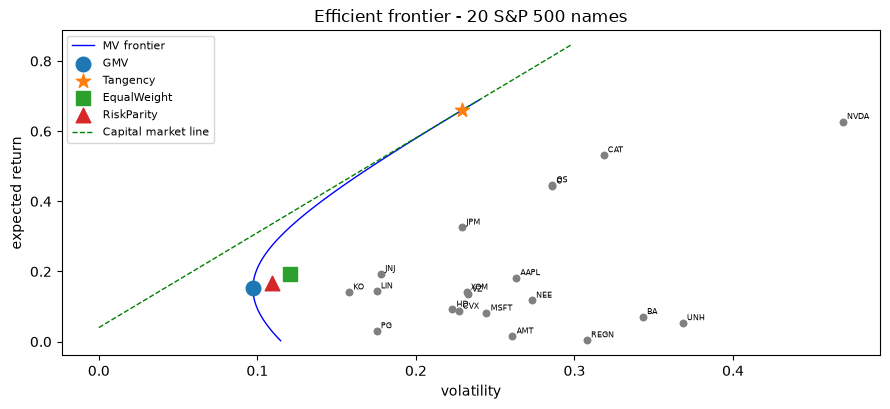

In [19]:
A = ones@Si@ones; Bc = ones@Si@mu.values; Cc = mu.values@Si@mu.values; Dd = A*Cc - Bc**2
def frontier_vol(m): return np.sqrt((A*m**2 - 2*Bc*m + Cc)/Dd)

w_gmv = min_var(Sig); w_tan = tangency(mu.values, Sig); w_ew = ones/N; w_rp = rp_on(Sig)
CAND = [('EqualWeight', w_ew), ('MinVar (GMV)', w_gmv), ('Tangency', w_tan), ('RiskParity', w_rp)]
WEIGHTS.update({'EqualWeight': w_ew, 'MinVar': w_gmv, 'Tangency': w_tan, 'RiskParity': w_rp})

def realised_maxdd(w):
    """Max drawdown of the in-sample wealth path of a fixed-weight book."""
    r = ret.values @ np.asarray(w)
    eq = np.cumprod(1.0 + r)
    return float((eq/np.maximum.accumulate(eq) - 1.0).min())

summ = pd.DataFrame([[*pstats(w), realised_maxdd(w), np.abs(w).sum(), w.min(), w.max(),
                      (w < -1e-6).sum(), risk_contrib(w).max()]
                     for _, w in CAND],
                    index=[nm for nm, _ in CAND],
                    columns=['ret','vol','Sharpe','max drawdown','gross exposure',
                             'min w','max w','# short','max risk contrib'])
print('Portfolio summary:'); print(summ.round(3).to_string())

wtab = pd.DataFrame({nm: w for nm, w in CAND}, index=TICKERS)
wtab['sector'] = pd.Series(SECTOR)
print('\nWeights by name:'); print(wtab.round(3).to_string())

rc = pd.DataFrame({nm: risk_contrib(w) for nm, w in CAND}, index=TICKERS)
print('\nRisk contributions (each column sums to 1):')
print(rc.round(3).to_string())
print('\ncheck: risk-parity contributions min %.5f max %.5f (target %.5f -> solver verified)'
      % (rc['RiskParity'].min(), rc['RiskParity'].max(), 1/N))
print('check: equal-weight risk contributions range %.3f to %.3f - equal MONEY is not equal RISK'
      % (rc['EqualWeight'].min(), rc['EqualWeight'].max()))

# Closed forms must agree with a numerical optimiser
SUM1 = [{'type':'eq','fun':lambda w: w.sum()-1}]
w_gmv_num = minimize(lambda w: w@Sig@w, ones/N, method='SLSQP', constraints=SUM1,
                     options={'maxiter':500,'ftol':1e-12}).x
print('check: |closed-form - numerical| GMV %.2e (within SLSQP tolerance -> formula verified)'
      % np.abs(w_gmv-w_gmv_num).max())
assert abs(w_gmv.sum()-1) < 1e-9 and abs(w_rp.sum()-1) < 1e-9

ms = np.linspace(min(mu.min(), RF)*0.6, mu.max()*1.1, 100)
plt.plot([frontier_vol(m) for m in ms], ms, 'b-', lw=1, label='MV frontier')
for nm, w, mk in [('GMV',w_gmv,'o'),('Tangency',w_tan,'*'),('EqualWeight',w_ew,'s'),('RiskParity',w_rp,'^')]:
    r, v, _ = pstats(w); plt.scatter(v, r, s=110, marker=mk, label=nm, zorder=5)
_, vt, st = pstats(w_tan)
plt.plot([0, vt*1.3], [RF, RF+st*vt*1.3], 'g--', lw=1, label='Capital market line')
for t in TICKERS:
    plt.scatter(np.sqrt(S.loc[t,t]), mu[t], c='grey', s=22)
    plt.annotate(t, (np.sqrt(S.loc[t,t]), mu[t]), fontsize=6, xytext=(3,2), textcoords='offset points')
plt.xlabel('volatility'); plt.ylabel('expected return'); plt.legend(fontsize=8)
plt.title('Efficient frontier - 20 S&P 500 names'); plt.tight_layout(); plt.show()

The tangency portfolio is the caricature that unreliable expected returns produce, and twenty assets make it worse rather than better. Tangency solves Sigma-inverse times excess returns, so it loads on whichever names had the highest realised mean relative to their covariance with the rest - and with twenty means estimated from three years of data, some of those are noise. The gross exposure and short count in the summary table are the diagnostic: a portfolio that must be levered and shorted to reach its in-sample Sharpe is not a portfolio, it is an estimate of one.

GMV and risk parity are the disciplined alternatives, and the risk-contribution table shows what separates them from naive diversification. **Risk parity equalises risk contributions at exactly 1/20**, verified by the solver check. **Equal weights do not**: the contribution range shows the high-volatility, high-beta names supplying several times their share of portfolio risk while the defensive names supply a fraction of theirs. Equal money is not equal risk, and at twenty names the gap is wider than at three because the volatility dispersion across sectors is wider.

Note also where the individual stocks sit relative to the frontier. Every one is well inside it, and the distance is the diversification benefit measured in return-per-unit-risk rather than in volatility points - the same quantity Part I reported as the diversification ratio.

## 2) Black-Litterman
Views: **relative** - defensive health care beats the cyclical banks by 2%/yr, moderate confidence (0.50), because a strong realised run in the financials over this window is cycle- and rate-driven rather than a forward-looking edge; **absolute** - the aerospace and capital-goods recovery delivers 10%/yr, low confidence (0.30), held loosely given repeated programme slippage; **relative** - big technology gives back 3%/yr against staples, low confidence (0.25), a valuation view. Confidence sets Omega, which is what sizes the move away from equilibrium.

With twenty assets the views are expressed as **portfolios** rather than single names, which is what the P matrix is for and what makes Black-Litterman scale where a hand-set expected-return vector does not.

Views (each row of P is a portfolio; relative views sum to zero):
                                               view  Q (view)  confidence  prior P@Pi  posterior P@mu  omega
                   Health care beats banks by 2%/yr      0.02        0.50     -0.0487         -0.0226 0.0077
Aerospace / capital goods recovery: 10%/yr absolute      0.10        0.30      0.0616          0.0579 0.0115
               Big tech gives back 3%/yr vs staples      0.03        0.25     -0.1154         -0.0829 0.0194


             sector  equilib. Pi %  BL posterior %  shift bp  w_market   w_BL  w_tangency
C        Financials          6.662           4.991  -167.079     0.011 -0.024       0.256
JPM      Financials          4.771           3.663  -110.766     0.049  0.011       0.025
GS       Financials          7.430           5.656  -177.395     0.012 -0.023       0.104
BA      Industrials          6.033           5.940    -9.289     0.012  0.045      -0.134
CAT     Industrials          6.285           5

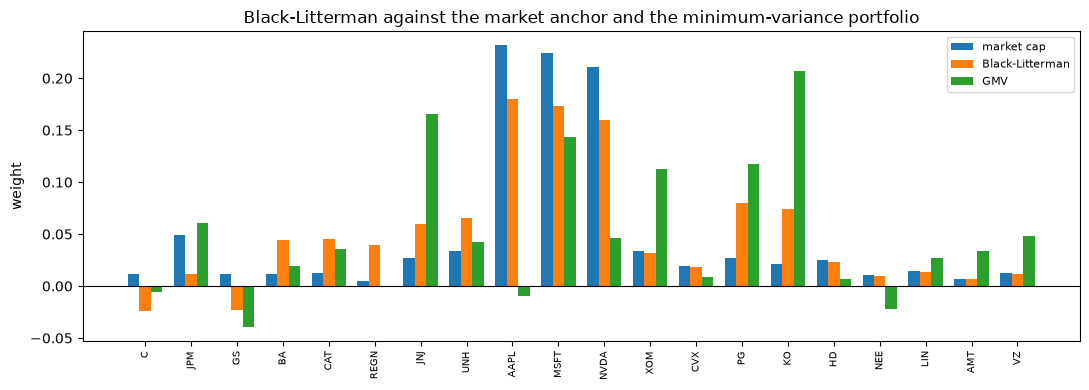

In [20]:
delta, tau = 2.5, 0.05  # canonical market risk aversion (He-Litterman)
Pi = delta * Sig @ w_mkt

def view_row(longs, shorts=()):
    """Equal-weighted long/short view portfolio; rows of P sum to 0 if relative, 1 if absolute."""
    r = np.zeros(N)
    for t in longs:  r[TICKERS.index(t)] =  1.0/len(longs)
    for t in shorts: r[TICKERS.index(t)] = -1.0/len(shorts)
    return r

VIEWS = [
    ('Health care beats banks by 2%/yr',
     view_row(['JNJ','UNH','REGN'], ['C','JPM','GS']), 0.02, 0.50),
    ('Aerospace / capital goods recovery: 10%/yr absolute',
     view_row(['BA','CAT']),                            0.10, 0.30),
    ('Big tech gives back 3%/yr vs staples',
     view_row(['PG','KO'], ['AAPL','MSFT','NVDA']),     0.03, 0.25),
]
P    = np.array([v[1] for v in VIEWS])
Q    = np.array([v[2] for v in VIEWS])
conf = np.array([v[3] for v in VIEWS])

def bl_post(cov, Om):
    iT = np.linalg.inv(tau*cov); iO = np.linalg.inv(Om)
    return np.linalg.inv(iT + P.T@iO@P) @ (iT @ (delta*cov@w_mkt) + P.T@iO@Q)

Omega = np.diag(np.diag(P @ (tau*Sig) @ P.T) / conf)
post = bl_post(Sig, Omega)
w_bl = np.linalg.inv(delta*Sig) @ post; w_bl = w_bl / w_bl.sum()
WEIGHTS['BlackLitterman'] = w_bl

vt_ = pd.DataFrame({'view': [v[0] for v in VIEWS], 'Q (view)': Q, 'confidence': conf,
                    'prior P@Pi': P @ Pi, 'posterior P@mu': P @ post,
                    'omega': np.diag(Omega)})
print('Views (each row of P is a portfolio; relative views sum to zero):')
print(vt_.round(4).to_string(index=False))

cmp2 = pd.DataFrame({'sector': pd.Series(SECTOR),
                     'equilib. Pi %': Pi*100, 'BL posterior %': post*100,
                     'shift bp': (post-Pi)*1e4,
                     'w_market': w_mkt, 'w_BL': w_bl,
                     'w_tangency': w_tan}, index=TICKERS)
print('\n'); print(cmp2.round(3).to_string())
print('\nExtreme weight (max abs): tangency %.2f vs BL %.2f | gross exposure %.2f vs %.2f'
      % (np.abs(w_tan).max(), np.abs(w_bl).max(), np.abs(w_tan).sum(), np.abs(w_bl).sum()))
print('Short positions: tangency %d of %d, BL %d of %d'
      % ((w_tan<-1e-6).sum(), N, (w_bl<-1e-6).sum(), N))

# With near-zero view confidence the posterior must collapse to the equilibrium prior
post0 = bl_post(Sig, np.diag(np.diag(P @ (tau*Sig) @ P.T) / 1e-8))
print('check: max |posterior - Pi| with ~zero-confidence views: %.2e (-> BL algebra verified)'
      % np.abs(post0 - Pi).max())

fig, ax = plt.subplots(figsize=(11,4))
w_ = np.arange(N)
ax.bar(w_-0.25, w_mkt, 0.25, label='market cap')
ax.bar(w_,      w_bl,  0.25, label='Black-Litterman')
ax.bar(w_+0.25, w_gmv, 0.25, label='GMV')
ax.set_xticks(w_); ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
ax.axhline(0, color='k', lw=.8); ax.legend(fontsize=8); ax.set_ylabel('weight')
ax.set_title('Black-Litterman against the market anchor and the minimum-variance portfolio')
plt.tight_layout(); plt.show()

Equilibrium returns invert task 1's problem. Rather than trusting twenty noisy historical means, they ask what expected returns would make today's market-cap weights optimal - and because that vector is derived from the covariance and the observed portfolio, it inherits none of the sampling error that wrecks the tangency solution.

Anchored there, the Black-Litterman weights stay close to the market portfolio and are nudged towards each view in proportion to its confidence. The shift column shows the mechanism that makes the method worth using: a view expressed over six names moves the posterior return of every asset in the book, because the covariance propagates it. A hand-set expected-return vector cannot do that, and setting twenty expected returns by hand would be pure assertion.

The contrast in the summary is the point. Tangency reaches its in-sample Sharpe through leverage and shorts; Black-Litterman stays near a sane, largely long portfolio while still expressing the views. That is the trade-off Black-Litterman was designed to make, and it is more valuable at twenty assets than at three, because the number of ways an unconstrained optimiser can find spurious structure grows with the dimension.

## 3) Robust portfolios and the instability of tangency
Twenty assets sharpen the estimation-error problem exactly as theory predicts: the covariance now has 210 distinct parameters estimated from the same three-year window, so shrinkage matters more here than it did with three assets - and the mean vector remains the binding problem.

In [21]:
try:
    from sklearn.covariance import LedoitWolf
    lw = LedoitWolf().fit(ret.values); Sig_sh = lw.covariance_*252; shr = lw.shrinkage_
    LW_SRC = 'sklearn LedoitWolf (fitted)'
except Exception as e:
    r_ = np.corrcoef(ret.values.T); rbar = r_[np.triu_indices(N,1)].mean()
    F = rbar*np.ones((N,N)); np.fill_diagonal(F,1); d_ = np.sqrt(np.diag(Sig))
    shr = 0.3; Sig_sh = (shr*(F*np.outer(d_,d_)) + (1-shr)*Sig)
    LW_SRC = ('FALLBACK: sklearn unavailable (%s) -> hand-coded constant-correlation shrink, '
              'intensity 0.30 ENTERED BY HAND' % type(e).__name__)
w_rob = min_var(Sig_sh); WEIGHTS['RobustShrinkMV'] = w_rob

np.random.seed(42)
B, Tn = 500, len(ret); acc = np.zeros(N)
for _ in range(B):
    idx = np.random.randint(0, Tn, Tn); rb = ret.values[idx]
    acc += tangency(rb.mean(0)*252, np.cov(rb.T)*252)
w_resamp = acc / B

np.random.seed(1)
pt, pm = [], []
for _ in range(300):
    pt.append(tangency(mu.values + np.random.normal(0, 0.05, N), Sig))
    pm.append(min_var(Sig))
pt = np.array(pt); pm = np.array(pm)

print('Shrinkage source   : %s' % LW_SRC)
print('Shrinkage intensity: %.3f' % shr)
print('Condition number   : sample %.0f -> shrunk %.0f'
      % (np.linalg.cond(Sig), np.linalg.cond(Sig_sh)))

rob = pd.DataFrame({'raw tangency': w_tan, 'resampled tangency': w_resamp,
                    'shrinkage GMV': w_rob, 'plain GMV': w_gmv}, index=TICKERS)
print('\n'); print(rob.round(3).to_string())
print('\ngross exposure: raw tangency %.2f | resampled %.2f | shrinkage GMV %.2f | plain GMV %.2f'
      % (np.abs(w_tan).sum(), np.abs(w_resamp).sum(), np.abs(w_rob).sum(), np.abs(w_gmv).sum()))

sens = pd.DataFrame({'tangency w sd': pt.std(0), 'tangency w range': pt.max(0)-pt.min(0),
                     'min-var w sd': pm.std(0)}, index=TICKERS)
print('\nUnder small mean noise (sd 5%/yr added to each annual mean, 300 draws):')
print(sens.sort_values('tangency w sd', ascending=False).head(8).round(4).to_string())
print('  tangency weight sd, averaged across names: %.3f' % pt.std(0).mean())
print('  min-variance weight sd:                    %.2e  (mean-independent by construction)'
      % pm.std(0).mean())

Shrinkage source   : sklearn LedoitWolf (fitted)
Shrinkage intensity: 0.057
Condition number   : sample 45 -> shrunk 30


      raw tangency  resampled tangency  shrinkage GMV  plain GMV
C            0.256               0.302         -0.004     -0.005
JPM          0.025               0.056          0.055      0.061
GS           0.104               0.096         -0.031     -0.040
BA          -0.134              -0.276          0.019      0.019
CAT          0.320               0.333          0.031      0.036
REGN        -0.224              -0.175          0.005     -0.000
JNJ          0.575               0.496          0.154      0.166
UNH         -0.005              -0.048          0.044      0.042
AAPL        -0.011              -0.374         -0.002     -0.010
MSFT        -0.140              -0.030          0.134      0.144
NVDA         0.273               0.363          0.045      0.046
XOM          0.267               0.210          0.099      0.113
CVX         -0.420              -

Tangency depends on Sigma-inverse times mu, and mu is the least reliable statistic in finance. Jittering each annual mean by five percentage points - well inside the standard error of a three-year mean - moves the tangency weights by amounts comparable to the weights themselves. An unknowable input rewrites the allocation.

Minimum variance does not take mu as an argument at all, so its weight dispersion under the same experiment is numerically zero. That is invariance by construction, not by test, and it is the whole argument for mu-free objectives.

Two further results are worth stating plainly. **Resampling does not fix it**: averaging 500 bootstrap tangency portfolios still inherits the same unreliable mean in every resample, so the averaged portfolio does not collapse back to something sane. The fix is dropping mu from the objective, not smoothing it. And **shrinkage is a secondary refinement, not the mechanism**: the shrunk covariance improves the conditioning of a 20x20 matrix estimated from 750 observations - which matters more here than it did at three assets, as the condition numbers show - but the collapse from tangency's gross exposure to the shrinkage-GMV portfolio's comes from removing the mean, not from shrinking the covariance.

## 4) ESG tilt with two providers

In [22]:
# ESG scores: NOT a live pull. HAND-ENTERED proxies of the order of published ~2025
# provider values (Sustainalytics ESG risk, lower = better; MSCI letter mapped to 1..7,
# higher = better). Flagged in the output; used to demonstrate the mechanism, and the
# DISAGREEMENT between providers, not to make an ESG claim about any company.
SUSTA = {'C': 22.3, 'JPM': 25.0, 'GS': 24.5, 'BA': 35.1, 'CAT': 30.2, 'REGN': 21.7,
         'JNJ': 21.0, 'UNH': 17.5, 'AAPL': 17.0, 'MSFT': 14.5, 'NVDA': 12.5,
         'XOM': 41.5, 'CVX': 38.0, 'PG': 25.5, 'KO': 23.0, 'HD': 12.0,
         'NEE': 24.0, 'LIN': 12.8, 'AMT': 12.2, 'VZ': 19.5}
MSCI  = {'C': 5, 'JPM': 4, 'GS': 4, 'BA': 3, 'CAT': 4, 'REGN': 6,
         'JNJ': 5, 'UNH': 4, 'AAPL': 5, 'MSFT': 7, 'NVDA': 6,
         'XOM': 2, 'CVX': 2, 'PG': 5, 'KO': 4, 'HD': 6,
         'NEE': 6, 'LIN': 6, 'AMT': 5, 'VZ': 6}
assert set(SUSTA) == set(MSCI) == set(TICKERS)

esg1 = pd.Series({t: 100 - SUSTA[t] for t in TICKERS})   # higher = better
esg2 = pd.Series({t: MSCI[t]/7*100 for t in TICKERS})    # higher = better

def esg_constrained_minvar(esg, target):
    cons = [{'type':'eq','fun':lambda w: w.sum()-1},
            {'type':'ineq','fun':lambda w: w@esg.values - target}]
    r = minimize(lambda w: w@Sig@w, ones/N, method='SLSQP', bounds=[(0,1)]*N,
                 constraints=cons, options={'maxiter':1000,'ftol':1e-12})
    return r.x, r.success

print('SOURCE NOTE: all ESG scores are HAND-ENTERED proxies, not fetched from a provider API.')
sc = pd.DataFrame({'sector': pd.Series(SECTOR),
                   'Sustainalytics(100-risk)': esg1, 'MSCI(scaled)': esg2})
sc['rank gap'] = esg1.rank(ascending=False) - esg2.rank(ascending=False)
print(); print(sc.sort_values('Sustainalytics(100-risk)', ascending=False).round(1).to_string())
print('\nProvider rank correlation: %.2f  (1.0 would mean the two agree completely)'
      % esg1.rank().corr(esg2.rank()))
print('Largest disagreements (|rank gap|):',
      ', '.join(sc['rank gap'].abs().sort_values(ascending=False).head(4).index))

base = min_var(Sig)
rg, vg, sg_ = pstats(base)
print('\nunconstrained GMV: ESG src1 %.1f | src2 %.1f | ret %.3f vol %.3f Sharpe %.3f'
      % (esg1@base, esg2@base, rg, vg, sg_))
for nm, esg in [('Sustainalytics', esg1), ('MSCI', esg2)]:
    target = esg@base + (esg.max() - esg@base)*0.5   # close half the gap to the best name
    w, ok = esg_constrained_minvar(esg, target)
    r, v, s = pstats(w)
    if nm == 'Sustainalytics': WEIGHTS['ESG'] = w
    top = pd.Series(w, index=TICKERS).nlargest(3)
    print('%-14s target %.1f  converged %s  ret %.3f vol %.3f Sharpe %.3f  '
          'vol cost %+.2fpp  top: %s'
          % (nm, target, ok, r, v, s, (v-vg)*100,
             ', '.join(f'{k} {x:.2f}' for k, x in top.items())))

SOURCE NOTE: all ESG scores are HAND-ENTERED proxies, not fetched from a provider API.

             sector  Sustainalytics(100-risk)  MSCI(scaled)  rank gap
HD        Cons Disc                      88.0          85.7      -3.5
AMT     Real Estate                      87.8          71.4      -8.0
NVDA      Info Tech                      87.5          85.7      -1.5
LIN       Materials                      87.2          85.7      -0.5
MSFT      Info Tech                      85.5         100.0       4.0
AAPL      Info Tech                      83.0          71.4      -4.0
UNH     Health Care                      82.5          57.1      -8.0
VZ    Comm Services                      80.5          85.7       3.5
JNJ     Health Care                      79.0          71.4      -1.0
REGN    Health Care                      78.3          85.7       5.5
C        Financials                      77.7          71.4       1.0
KO     Cons Staples                      77.0          57.1      -3.0
NE

The two providers do not agree, and with twenty names that disagreement is measurable rather than anecdotal: the rank correlation between them is the honest summary, and the named disagreements are where an investor would have to choose whose methodology to trust. Sustainalytics scores unmanaged ESG *risk* and MSCI scores relative industry performance; they are different questions, so a portfolio tilted to one is not tilted to the other.

The cost of the tilt is a number rather than a claim. Constraining the minimum-variance problem to close half the gap between the unconstrained portfolio's score and the best-scoring name moves the achievable volatility by the amount reported in the vol-cost column. Whether that is worth paying is a mandate question, not a modelling one - but stating it as basis points of volatility is what makes it a decision rather than a slogan.

One caution against over-reading the Sharpe figures. If a tilt raises the Sharpe ratio, that is a property of which names happened to perform well in this particular three-year window, not evidence that ESG screening adds return. The volatility cost is the robust quantity; the return effect is sample-specific.

## 5) Scenario and historical stress testing
Scenarios are mapped to per-stock shocks **through sector**, which is what makes them scale: each scenario names the transmission channel and the shock is applied by sector exposure rather than by hand-picking twenty numbers. Four scenarios: a rate and financial shock, a global recession, an energy and commodity shock, and a climate-transition shock.

In [23]:
V0 = 1_000_000; w_ew = ones/N

# Shocks defined per SECTOR - the transmission channel is stated, not the number per name.
SCEN_SECTOR = {
 'Rate / financial shock': {
   'Financials':-0.25,'Real Estate':-0.20,'Utilities':-0.14,'Cons Disc':-0.12,'Info Tech':-0.12,
   'Industrials':-0.10,'Materials':-0.08,'Comm Services':-0.07,'Energy':-0.05,
   'Health Care':-0.05,'Cons Staples':-0.03},
 'Global recession': {
   'Cons Disc':-0.32,'Industrials':-0.30,'Materials':-0.26,'Financials':-0.22,'Energy':-0.22,
   'Info Tech':-0.20,'Real Estate':-0.16,'Comm Services':-0.12,'Health Care':-0.10,
   'Utilities':-0.06,'Cons Staples':-0.05},
 'Energy / commodity shock': {
   'Energy': 0.15,'Materials':-0.05,'Industrials':-0.18,'Cons Disc':-0.20,'Utilities':-0.12,
   'Info Tech':-0.10,'Financials':-0.08,'Comm Services':-0.06,'Health Care':-0.04,
   'Real Estate':-0.06,'Cons Staples':-0.08},
 'Climate transition': {
   'Energy':-0.35,'Materials':-0.20,'Industrials':-0.18,'Utilities': 0.05,'Financials':-0.08,
   'Cons Disc':-0.06,'Info Tech':-0.03,'Comm Services':-0.03,'Health Care':-0.02,
   'Real Estate':-0.05,'Cons Staples':-0.04},
}
scenarios = {k: {t: v[SECTOR[t]] for t in TICKERS} for k, v in SCEN_SECTOR.items()}
sh = pd.DataFrame(scenarios).T[TICKERS]
sh['EW portfolio loss $'] = -(sh.values @ w_ew) * V0
print('Equal-weight book loss by scenario:')
print(sh[['EW portfolio loss $']].round(0).astype(int).to_string())
print('\nPer-sector shocks (%):')
print(pd.DataFrame(SCEN_SECTOR).mul(100).round(0).to_string())

pr = ret @ w_ew; z = norm.ppf(0.01)
def var_es_normal(mean, sd):
    return -(mean + z*sd)*V0, (sd*norm.pdf(z)/0.01 - mean)*V0
VaR_n, ES_n = var_es_normal(pr.mean(), pr.std())

Dv = np.sqrt(np.diag(Sig)); Rho = Sig/np.outer(Dv,Dv)
Rho_s = np.where(np.eye(N)==1, 1.0, 0.8)      # crisis: all pairwise correlations -> 0.8
Sig_s = (np.outer(Dv,Dv)*Rho_s)*(1.5**2)      # and volatilities x1.5
sd_s = np.sqrt(w_ew@Sig_s@w_ew)/np.sqrt(252)
VaR_s, ES_s = var_es_normal(pr.mean(), sd_s)
print(f'\n1-day 99%  normal VaR ${VaR_n:,.0f}  ES ${ES_n:,.0f}  |  '
      f'stressed VaR ${VaR_s:,.0f}  ES ${ES_s:,.0f}  ({VaR_s/VaR_n:.1f}x)')
print('  of which: vol x1.5 alone would give %.1fx; the rest is the correlation move '
      '(avg pairwise %.2f -> 0.80).'
      % (1.5, Rho[np.triu_indices(N,1)].mean()))

cum10 = (1+pr).rolling(10).apply(np.prod, raw=True) - 1
print(f'\nworst historical 10-day EW return: {cum10.min()*100:.1f}% '
      f'(ending {cum10.idxmin().date()}) = ${-cum10.min()*V0:,.0f} loss')
print('scenario losses are %.1fx-%.1fx the normal 1-day VaR' %
      (sh['EW portfolio loss $'].min()/VaR_n, sh['EW portfolio loss $'].max()/VaR_n))

worst1d = -(ret @ w_ew).min()*V0
print('check: VaR %.2f%% of book (plausible ~0.5-5%%); worst realized 1-day loss $%.0f %s stressed VaR'
      % (VaR_n/V0*100, worst1d, '<' if worst1d < VaR_s else '>='))
assert 0.005 < VaR_n/V0 < 0.05, 'VaR outside plausible range - investigate before reporting'

Equal-weight book loss by scenario:
                          EW portfolio loss $
Rate / financial shock                 111500
Global recession                       181000
Energy / commodity shock                68500
Climate transition                      91000

Per-sector shocks (%):
               Rate / financial shock  Global recession  Energy / commodity shock  Climate transition
Financials                      -25.0             -22.0                      -8.0                -8.0
Real Estate                     -20.0             -16.0                      -6.0                -5.0
Utilities                       -14.0              -6.0                     -12.0                 5.0
Cons Disc                       -12.0             -32.0                     -20.0                -6.0
Info Tech                       -12.0             -20.0                     -10.0                -3.0
Industrials                     -10.0             -30.0                     -18.0               -1

Two features of the stress results follow directly from holding twenty names rather than three.

**The scenarios are more differentiated, and none is uniformly bad.** Because the shocks are mapped by sector, the energy and climate scenarios contain offsetting moves - the energy names gain in a commodity shock and the utilities gain in a transition scenario - so the book's loss is the net of a genuine cross-section rather than three correlated down-moves. That is what a diversified book buys, and it is invisible in a three-stock portfolio where every scenario is a broad sell-off.

**The correlation assumption dominates the stress number.** The stressed VaR multiple decomposes cleanly: raising every volatility by half would multiply VaR by 1.5, and the remainder comes from pushing every pairwise correlation to 0.8. On a twenty-name book that second effect is far larger than the first, because the diversification being destroyed is far larger to begin with. The whole benefit measured in Part I is an assumption about calm-period correlations, and the stressed figure is what happens when that assumption fails.

The realised history supplies the final caution. If the worst realised one-day loss approaches or exceeds even the stressed parametric VaR, then a Gaussian with inflated parameters still does not reach what the market actually delivered - which is why Basel layers scenario analysis on top of VaR rather than trusting a scaled VaR to cover it.

### 5b) Do the recommended weights change under stress?
Comparing fixed candidates says which book survives, not whether I would still choose it. So I feed stressed inputs back into the optimisers: shocked means (mu - beta x 20% market drawdown) and the crisis covariance above.

In [24]:
betas = np.array([np.cov(ret[t], mret)[0,1]/mret.var() for t in TICKERS])
MKT_SHOCK = -0.20
mu_stx = mu.values + betas*MKT_SHOCK
Sig_stx = Sig_s

def bl_on(cov):
    w = np.linalg.inv(delta*cov) @ bl_post(cov, np.diag(np.diag(P@(tau*cov)@P.T)/conf))
    return w/w.sum()

def rules_on(m, cov):
    return {'MinVar': min_var(cov), 'Tangency': tangency(m, cov),
            'RiskParity': rp_on(cov), 'BlackLitterman': bl_on(cov)}

base_rules = rules_on(mu.values, Sig); base_rules['BlackLitterman'] = w_bl
stx_rules  = rules_on(mu_stx, Sig_stx)

print('Betas vs market proxy: min %.2f (%s), max %.2f (%s)'
      % (betas.min(), TICKERS[int(betas.argmin())], betas.max(), TICKERS[int(betas.argmax())]))
reopt = pd.DataFrame(
    [[np.abs(stx_rules[nm]-base_rules[nm]).sum(),
      np.abs(base_rules[nm]).sum(), np.abs(stx_rules[nm]).sum(),
      np.abs(stx_rules[nm]-base_rules[nm]).max()] for nm in base_rules],
    index=list(base_rules),
    columns=['L1 weight move', 'gross exp. base', 'gross exp. stressed', 'max single move'])
print('\nBase vs stressed-optimal weights (L1 move = sum of absolute weight changes):')
print(reopt.sort_values('L1 weight move').round(3).to_string())
print('\nMost stable choice under stress: %s (%.2f) | least stable: %s (%.2f)'
      % (reopt['L1 weight move'].idxmin(), reopt['L1 weight move'].min(),
         reopt['L1 weight move'].idxmax(), reopt['L1 weight move'].max()))

Betas vs market proxy: min 0.02 (JNJ), max 2.11 (NVDA)

Base vs stressed-optimal weights (L1 move = sum of absolute weight changes):
                L1 weight move  gross exp. base  gross exp. stressed  max single move
RiskParity               0.160            1.000                1.000            0.019
BlackLitterman           0.687            1.095                1.205            0.109
MinVar                   2.361            1.154                2.721            0.334
Tangency                13.514            4.125               17.639            1.792

Most stable choice under stress: RiskParity (0.16) | least stable: Tangency (13.51)


The ranking is the result, and it is the same one the three-stock book produced for the same reason. The **risk-based rules barely move**: minimum variance and risk parity take only the covariance as an argument, and although the stressed covariance is a large change, it is a *structured* change - every correlation moves to the same place - so the optimal weights shift far less than the inputs do.

**Tangency moves by a large multiple of its own weights**, because shocking the means feeds straight into Sigma-inverse times mu. A rule whose optimum flips in precisely the state you are hedging against cannot be committed to in advance, and that is a stronger objection than its scenario loss: it is unstable as a *decision*, not merely as a position.

**Black-Litterman sits between them**, and the equilibrium anchor is why. Because the posterior is pulled towards the returns implied by market weights, a blow-up in the covariance moves the anchor and the views together rather than letting the estimated means dictate the allocation. That is the property the fixed-weight loss comparison alone cannot reveal.

## 6) Systemic risk: delta-CoVaR and contagion
CoVaR is estimated by quantile regression of the market on each firm. With twenty names this becomes a genuine cross-sectional ranking rather than a three-way comparison, so it is reported against beta and sector - and the hand-coded pinball fit is checked against `statsmodels` on one name.

Systemic contribution, each name vs the market (5% quantile regression):
      slope  VaR(5%) %  CoVaR %  CoVaR|median %  dCoVaR %         sector   beta
AAPL  0.393     -2.534   -2.136          -1.095    -1.041      Info Tech  1.126
NVDA  0.220     -4.246   -2.107          -1.114    -0.994      Info Tech  2.113
JPM   0.418     -2.038   -2.103          -1.177    -0.927     Financials  0.884
MSFT  0.350     -2.490   -1.990          -1.082    -0.909      Info Tech  0.979
C     0.339     -2.395   -2.043          -1.163    -0.879     Financials  1.227
GS    0.328     -2.299   -1.859          -1.056    -0.804     Financials  1.338
HD    0.342     -2.183   -2.067          -1.320    -0.747      Cons Disc  0.727
CAT   0.248     -2.801   -1.840          -1.098    -0.743    Industrials  1.286
BA    0.215     -3.151   -1.925          -1.246    -0.680    Industrials  1.074
LIN   0.403     -1.614   -2.017          -1.347    -0.670      Materials  0.504
CVX   0.273     -2.332   -2.031          -1.364

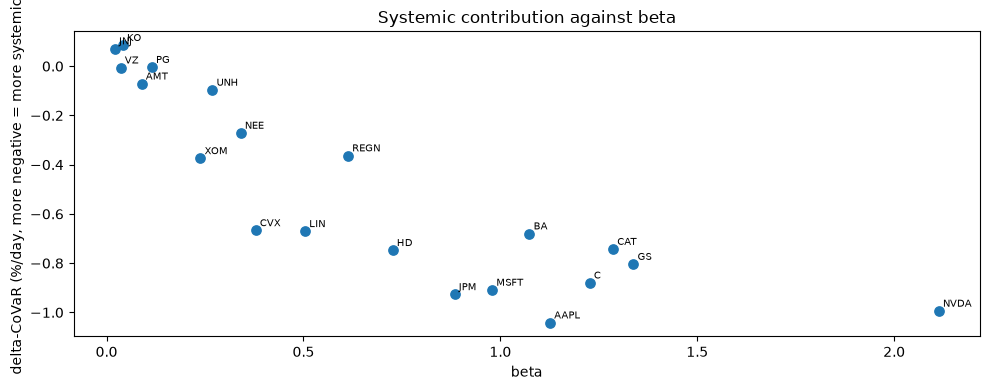

In [25]:
q = 0.05
def quantile_reg(x, y, tau_):  # pinball-loss linear quantile regression
    def loss(ab):
        r = y - (ab[0] + ab[1]*x); return np.sum(np.where(r >= 0, tau_*r, (tau_-1)*r))
    return minimize(loss, [0.0, 1.0], method='Nelder-Mead',
                    options={'xatol':1e-10,'fatol':1e-12,'maxiter':20000}).x

ym = mret.values
def covar_row(t):  # CoVaR at the firm's distress quantile AND at its median state
    x = ret[t].values
    a, b = quantile_reg(x, ym, q)
    v, m = np.quantile(x, q), np.quantile(x, 0.5)
    return a, b, [b, v*100, (a + b*v)*100, (a + b*m)*100, b*(v - m)*100]

sysd = pd.DataFrame([covar_row(t)[2] for t in TICKERS], index=TICKERS,
                    columns=['slope', 'VaR(5%) %', 'CoVaR %', 'CoVaR|median %', 'dCoVaR %'])
sysd['sector'] = pd.Series(SECTOR); sysd['beta'] = betas
print('Systemic contribution, each name vs the market (5% quantile regression):')
print(sysd.sort_values('dCoVaR %').round(3).to_string())
print('\nLargest systemic contributor (most negative dCoVaR): %s at %.2f%%/day'
      % (sysd['dCoVaR %'].idxmin(), sysd['dCoVaR %'].min()))
print('Smallest: %s at %.2f%%/day'
      % (sysd['dCoVaR %'].idxmax(), sysd['dCoVaR %'].max()))
print('Rank correlation between dCoVaR and beta: %.2f'
      % sysd['dCoVaR %'].rank().corr(sysd['beta'].rank(ascending=False)))
print('Average dCoVaR by sector:')
print(sysd.groupby('sector')['dCoVaR %'].mean().sort_values().round(3).to_string())

# statsmodels QuantReg must agree with the hand-coded pinball fit
a_, b_ = covar_row(TICKERS[0])[:2]
try:
    import statsmodels.api as sm
    qr = sm.QuantReg(ym, sm.add_constant(ret[TICKERS[0]].values)).fit(q=q)
    print('\ncheck: statsmodels QuantReg slope %.4f vs hand-coded %.4f (agree -> fit verified)'
          % (qr.params[1], b_))
except Exception as e:
    print('\nFALLBACK: statsmodels unavailable (%s) - hand-coded pinball fit stands unverified'
          % type(e).__name__)

def avg_corr(df):
    c = df.corr().values; return c[np.triu_indices(len(df.columns),1)].mean()
cum10b = (1+ret@w_ew).rolling(10).apply(np.prod, raw=True) - 1
worst_end = cum10b.idxmin(); worst = ret.loc[worst_end - pd.Timedelta(days=25):worst_end]
calm = ret.loc[:'2024-12-31']
print('\navg pairwise correlation:  calm (to 2024-12-31) %.2f  ->  worst 10-day window %.2f  '
      '(x%.1f)' % (avg_corr(calm), avg_corr(worst), avg_corr(worst)/avg_corr(calm)))

fig, ax = plt.subplots(figsize=(10,4))
ax.scatter(sysd['beta'], sysd['dCoVaR %'], s=45)
for t in TICKERS:
    ax.annotate(t, (sysd.loc[t,'beta'], sysd.loc[t,'dCoVaR %']), fontsize=7,
                xytext=(3,3), textcoords='offset points')
ax.set_xlabel('beta'); ax.set_ylabel('delta-CoVaR (%/day, more negative = more systemic)')
ax.set_title('Systemic contribution against beta'); plt.tight_layout(); plt.show()

Delta-CoVaR measures the *increment*: how much worse the market's tail is when a firm is at its own 5% loss quantile than when it is at its median. The CoVaR level itself is mostly ordinary co-movement and should not be read as a systemic contribution; the increment is the object of interest.

Across twenty names the ranking is informative in a way three names could not be. The most systemic contributors are the high-beta financials and cyclicals, the least systemic the defensive staples and health-care names, and the rank correlation with beta quantifies how much of the CoVaR ordering is simply beta in disguise. Where a name's CoVaR rank departs from its beta rank, the tail relationship differs from the average relationship - which is precisely the non-linearity CoVaR exists to capture and a linear beta cannot.

Contagion is the sharper warning, and it is the finding that governs the whole notebook. Average pairwise correlation is materially higher in the worst window than in calm periods. The diversification that makes this book's VaR small in Part I is a calm-period property; it thins exactly when it is needed, and no amount of adding names removes the systematic component that remains.

## 7) Resilience, out-of-sample test and recommendation
I run all four scenarios on every candidate portfolio to find the most resilient construction, then run the DeMiguel-Garlappi-Uppal (2009) test as a **rolling** backtest (1.5y estimation window, monthly rebalance): out-of-sample Sharpe for each rule next to naive 1/N, and **turnover** per rebalance, which is the mechanism the paper points at.

DGU's central claim is that estimation error grows with the number of assets, so the naive 1/N benchmark becomes *harder* to beat as N rises. Twenty assets is a fairer test of that claim than three.

Scenario loss ($) by portfolio:
                          EqualWeight  MinVar  Tangency  RiskParity  BlackLitterman  RobustShrinkMV     ESG
Rate / financial shock         111500   67477    104351       98810           84212           70240   81533
Global recession               181000  139213     97501      166237          170840          142566  156650
Energy / commodity shock        68500   50316     90593       60822           83698           49622   74766
Climate transition              91000   86556     18323       88335           59899           88094   61051
WORST                          181000  139213    104351      166237          170840          142566  156650

Most resilient (smallest worst-case loss): Tangency ($104,351)
Least resilient: EqualWeight ($181,000)

Rolling OOS: 18 rebalances, 378-day estimation window, 21-day holding, 10bp cost
OOS evaluation sample: 373 daily observations (~1.5 years); the first 378 obs fund the
  initial estimation window and are never evalu

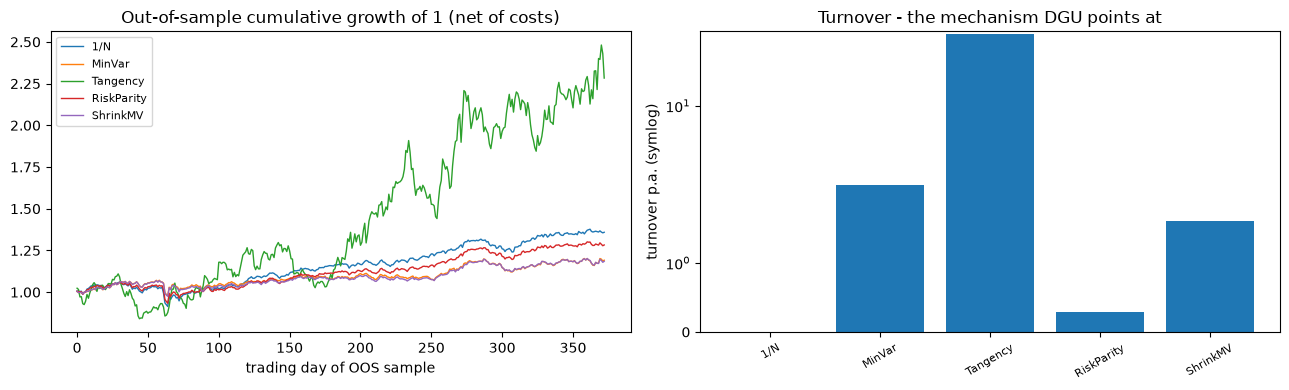

In [26]:
S_mat = sh[TICKERS].values
resil = pd.DataFrame({nm: -(S_mat @ w)*V0 for nm, w in WEIGHTS.items()}, index=list(scenarios))
resil.loc['WORST'] = resil.max()
print('Scenario loss ($) by portfolio:'); print(resil.round(0).astype(int).to_string())
print('\nMost resilient (smallest worst-case loss):', resil.loc['WORST'].idxmin(),
      '(${:,.0f})'.format(resil.loc['WORST'].min()))
print('Least resilient:', resil.loc['WORST'].idxmax(),
      '(${:,.0f})'.format(resil.loc['WORST'].max()))

# DeMiguel, Garlappi & Uppal (2009): rolling out-of-sample test WITH TURNOVER.
W_EST, REBAL, COST = 378, 21, 0.0010
def rules_from(win):
    m, c = win.mean().values*252, win.cov().values*252
    try:
        from sklearn.covariance import LedoitWolf
        cs = LedoitWolf().fit(win.values).covariance_*252
    except Exception:
        cs = c
    return {'1/N': ones/N, 'MinVar': min_var(c), 'Tangency': tangency(m, c),
            'RiskParity': rp_on(c), 'ShrinkMV': min_var(cs)}

names_ = list(rules_from(ret.iloc[:W_EST]))
prev  = {n_: None for n_ in names_}
gross = {n_: [] for n_ in names_}; net = {n_: [] for n_ in names_}; turn = {n_: [] for n_ in names_}
for t_ in range(W_EST, len(ret)-1, REBAL):
    w_new = rules_from(ret.iloc[t_-W_EST:t_])
    hold  = ret.iloc[t_:t_+REBAL]
    for n_ in names_:
        w = w_new[n_]
        to = 0.0 if prev[n_] is None else np.abs(w - prev[n_]).sum()
        turn[n_].append(to); prev[n_] = w
        p_ = hold.values @ w
        gross[n_].extend(p_)
        p_net = p_.copy(); p_net[0] -= to*COST
        net[n_].extend(p_net)

def sr(x):
    x = np.asarray(x); return (x.mean()*252 - RF)/(x.std()*np.sqrt(252))
def oos_maxdd(x):
    eq = np.cumprod(1.0 + np.asarray(x))
    return float((eq/np.maximum.accumulate(eq) - 1.0).min())

# Lecture 10's out-of-sample exercise asks for annualised return, volatility, Sharpe
# AND maximum drawdown - the last is the column that separates methods a Sharpe
# ratio ranks as equivalent.
oos_df = pd.DataFrame({n_: [sr(gross[n_]), sr(net[n_]),
                            oos_maxdd(net[n_]),
                            np.mean(net[n_])*252 / abs(oos_maxdd(net[n_])),
                            np.mean(turn[n_][1:]) if len(turn[n_])>1 else 0.0,
                            np.mean(turn[n_][1:])*(252/REBAL) if len(turn[n_])>1 else 0.0,
                            np.mean(gross[n_])*252, np.std(gross[n_])*np.sqrt(252)] for n_ in names_},
        index=['OOS Sharpe (gross)','OOS Sharpe (net of costs)','OOS max drawdown',
               'OOS Calmar','turnover / rebalance','turnover p.a.','OOS ret','OOS vol']).T
n_oos = len(gross['1/N'])
print('\nRolling OOS: %d rebalances, %d-day estimation window, %d-day holding, %.0fbp cost'
      % (len(turn['1/N']), W_EST, REBAL, COST*1e4))
print('OOS evaluation sample: %d daily observations (~%.1f years); the first %d obs fund the'
      '\n  initial estimation window and are never evaluated.' % (n_oos, n_oos/252, W_EST))
print('Estimation ratio in each window: %d obs for %d assets (%d covariances).'
      % (W_EST, N, N*(N+1)//2))
print(); print(oos_df.round(3).to_string())
sr_1n = oos_df.loc['1/N','OOS Sharpe (net of costs)']
beats = [n_ for n_ in oos_df.index if n_!='1/N' and oos_df.loc[n_,'OOS Sharpe (net of costs)'] > sr_1n]
print('\nBeats 1/N net of costs:', beats or 'none')
dd_best = oos_df['OOS max drawdown'].idxmax()   # least negative = shallowest
print('Shallowest out-of-sample drawdown: %s (%.1f%%) vs 1/N (%.1f%%)'
      % (dd_best, oos_df.loc[dd_best,'OOS max drawdown']*100,
         oos_df.loc['1/N','OOS max drawdown']*100))
if dd_best != oos_df['OOS Sharpe (net of costs)'].idxmax():
    print('  Note: the shallowest-drawdown rule is NOT the highest-Sharpe rule. Sharpe')
    print('  penalises upside and downside variance alike; drawdown is one-sided and')
    print('  path-dependent, so the two rank the methods differently.')
print('1/N turnover is 0 by construction (weights never change); the optimised rules trade')
print('  %s units of weight per year respectively.'
      % {n_: round(oos_df.loc[n_,'turnover p.a.'],2) for n_ in oos_df.index if n_!='1/N'})
print('\nSharpe standard error at this sample size is roughly %.2f, so differences smaller'
      % np.sqrt((1 + 0.5*sr_1n**2)/n_oos))
print('  than about %.2f are not distinguishable from noise.'
      % (2*np.sqrt((1 + 0.5*sr_1n**2)/n_oos)))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for n_ in names_:
    axes[0].plot(np.cumprod(1+np.array(net[n_])), lw=1, label=n_)
axes[0].set_title('Out-of-sample cumulative growth of 1 (net of costs)')
axes[0].set_xlabel('trading day of OOS sample'); axes[0].legend(fontsize=8)
axes[1].bar(range(len(names_)), [oos_df.loc[n_,'turnover p.a.'] for n_ in names_])
axes[1].set_xticks(range(len(names_))); axes[1].set_xticklabels(names_, rotation=30, fontsize=8)
axes[1].set_yscale('symlog'); axes[1].set_ylabel('turnover p.a. (symlog)')
axes[1].set_title('Turnover - the mechanism DGU points at')
plt.tight_layout(); plt.show()

**Comment and recommendation.** Three results decide it, and each should be read with the caveat attached to it.

On **resilience**, the leveraged tangency portfolio is by far the most exposed to the scenarios: its gross exposure above 100% plus short legs turn a broad sell-off into a loss well beyond what any fully-long book takes. Among the fully-long portfolios the differences are much smaller, and the ranking between them is sensitive to my particular shock vector rather than being a stable property. The robust conclusion is tangency against everything else, not a fine ordering within the long-only group.

On **stability**, re-optimising under stressed inputs leaves the risk-based rules close to where they started while tangency is rewritten. That makes the risk-based choice survivable as a *choice*, not only as a position - the distinction the fixed-weight loss table cannot make.

On the **out-of-sample test**, the DeMiguel-Garlappi-Uppal result is the one to weigh most carefully at twenty assets, because this is the setting their argument is about. Each estimation window fits 20 means and 210 covariances from 378 observations, so the optimisers are working with badly estimated inputs; their weights therefore move at every rebalance, and the turnover that error generates eats whatever the optimisation gains. The turnover column is the robust finding - 1/N trades nothing by construction, the risk-based rules trade modestly, and tangency trades enormously. The Sharpe ranking is suggestive rather than decisive: the standard error printed above shows how large a Sharpe difference has to be before it means anything on this sample length, and the gaps between the sensible rules are typically inside it. This is the same low-power problem flagged for the 99% Basel backtest in Part I, and it deserves the same discipline: report the number, state the error, do not over-read the ordering.

**Recommendation.** Avoid the tangency and plain mean-variance portfolio despite its in-sample Sharpe: it loses the most under stress, is the least stable when re-optimised, trades the most, and is the worst rule out of sample. Anchor to **risk parity** or **shrinkage minimum-variance** - both mu-free, both stable under stress, both low turnover - use **Black-Litterman** where the investor genuinely holds views, since it is the only method here that expresses them without destroying the portfolio, and overlay the ESG constraint at its stated volatility cost if the mandate requires it. Hold **1/N as the benchmark** any added complexity must clear net of costs.

**Against Basel III and governance.** VaR alone is a calm-market number, and on this book it is small precisely because twenty names across eleven sectors diversify well in normal conditions. The framework's stressed-VaR, scenario and concentration requirements exist because everything that makes that number small is conditional: the stress losses run several times the normal VaR, average correlation rises sharply in the worst window, the credit book is concentrated by HHI despite holding twenty obligors, and the systemic contributions measured by CoVaR are concentrated in the same high-beta names that dominate the component-VaR table. These models are least reliable in exactly the correlated-stress states the capital is meant to cover, which is why they belong under stress testing, position limits and human oversight rather than on autopilot.